### 1. Análisis Exploratorio y planteamiento del problema

Imports necesarios para análisis

In [2]:
import math
import random
import warnings
from collections import Counter, defaultdict
from ECommerce_Helper import ConstruirDistribucionDiaria, ConstruirResumenMuestraCargada, CargarEventosRepresentativosCsv
from ECommerce_Helper import FiltrarItemsTrainYProyectarSplits, SepararSesionesPorVentanasDeTiempo
from ECommerce_Models import EntrenarGru4Rec, EntrenarSasRec
from ECommerce_Experiments import ConstruirItemKnnRecomendador, ConstruirSequentialRulesRecomendador, ConstruirRecomendadorHibrido, ConstruirRecomendadorPopularidadReciente, ConstruirMetadatosItems, ConstruirRecomendadorRerankMetadatos
from ECommerce_TALE import ConstruirSesionesConTiempo, SepararSesionesPorVentanasDeTiempoTALE, FiltrarItemsTrainYProyectarSplitsTALE, LimitarCatalogoTALEPorPopularidad, ConstruirResumenSplitsTALE, EntrenarTALE, HiperparametrosTALE

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")


Configuracion general

In [3]:
DATA_PATH = "."
FILE_NAME = "2019-Nov.csv"

USE_COLS = [
    "event_time",
    "event_type",
    "product_id",
    "category_id",
    "category_code",
    "brand",
    "price",
    "user_id",
    "user_session",
]

DTYPES = {
    "event_type": "string",
    "product_id": "int64",
    "category_id": "string",
    "category_code": "string",
    "brand": "string",
    "price": "float32",
    "user_id": "Int64",
    "user_session": "string",
}

SESSION_SAMPLE_FRAC = 0.01 #Muestreo por sesion a lo largo de todo el mes.
CHUNK_SIZE = 1_000_000 #Tamano de lectura por chunks para no cargar el CSV completo.
MIN_SESSION_LEN = 2 #Filtra sesiones demasiado cortas
MIN_ITEM_SUPPORT = 5 #Elimina productos que aparecen muy pocas veces en el dataset
MAX_SESSION_LEN = 20 #Limita la longitud máxima del historial que se usa por sesión.
VALIDATION_DAYS = 3 #Ultimos dias reservados para validacion temporal.
TEST_DAYS = 3 #Ultimos dias reservados para test temporal.
TOP_KS = (5, 10, 20) #Define los valores de K para evaluar las recomendaciones
RANDOM_STATE = 42 #Semilla aleatoria

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)


Carga y preprocesamiento inicial

In [4]:
events = CargarEventosRepresentativosCsv(DATA_PATH, FILE_NAME, use_cols=USE_COLS, dtypes=DTYPES, session_sample_frac=SESSION_SAMPLE_FRAC, chunksize=CHUNK_SIZE,)

sample_summary = ConstruirResumenMuestraCargada(events)
daily_sample = ConstruirDistribucionDiaria(events)

print(f"Fraccion de muestreo por sesion: {SESSION_SAMPLE_FRAC:.2%}")
display(sample_summary)
display(daily_sample)
display(events.head())


Chunk 1: escaneadas=1,000,000, muestra acumulada=10,032
Chunk 2: escaneadas=2,000,000, muestra acumulada=19,964
Chunk 3: escaneadas=3,000,000, muestra acumulada=30,330
Chunk 4: escaneadas=4,000,000, muestra acumulada=40,460
Chunk 5: escaneadas=5,000,000, muestra acumulada=50,848
Chunk 6: escaneadas=6,000,000, muestra acumulada=61,420
Chunk 7: escaneadas=7,000,000, muestra acumulada=71,044
Chunk 8: escaneadas=8,000,000, muestra acumulada=81,341
Chunk 9: escaneadas=9,000,000, muestra acumulada=91,743
Chunk 10: escaneadas=10,000,000, muestra acumulada=101,651
Chunk 11: escaneadas=11,000,000, muestra acumulada=111,791
Chunk 12: escaneadas=12,000,000, muestra acumulada=121,348
Chunk 13: escaneadas=13,000,000, muestra acumulada=131,320
Chunk 14: escaneadas=14,000,000, muestra acumulada=140,786
Chunk 15: escaneadas=15,000,000, muestra acumulada=150,722
Chunk 16: escaneadas=16,000,000, muestra acumulada=160,876
Chunk 17: escaneadas=17,000,000, muestra acumulada=171,166
Chunk 18: escaneadas=18,

,metrica,valor
0,eventos_cargados,677781
1,sesiones_unicas,138013
2,usuarios_unicos,129134
3,productos_unicos,67792
4,fecha_min,2019-11-01 00:07:26+00:00
5,fecha_max,2019-11-30 23:59:03+00:00
6,dias_cubiertos,30


,date,event_count
0,2019-11-01,14607
1,2019-11-02,15731
2,2019-11-03,16081
3,2019-11-04,18352
4,2019-11-05,17451
5,2019-11-06,16949
6,2019-11-07,18105
7,2019-11-08,18400
8,2019-11-09,18525
9,2019-11-10,19640


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-20 11:11:41+00:00,view,58300004,2158174724725670855,unknown,polaris,40.389999,573882848,000052ae-8b53-42a9-a7b5-b91e0815c3d3
1,2019-11-23 07:55:18+00:00,view,23900200,2053013561814287111,unknown,barokko,11.070000,512677924,00005795-7758-472e-a2d9-d042a408d714
2,2019-11-23 07:55:40+00:00,view,23301148,2053013561956893455,unknown,unknown,20.490000,512677924,00005795-7758-472e-a2d9-d042a408d714
3,2019-11-23 07:55:58+00:00,view,23300426,2053013561956893455,unknown,unknown,21.750000,512677924,00005795-7758-472e-a2d9-d042a408d714
4,2019-11-23 07:56:13+00:00,view,23300474,2053013561956893455,unknown,unknown,57.220001,512677924,00005795-7758-472e-a2d9-d042a408d714


El dataset tiene una estructura adecuada para recomendacion secuencial, ya que cada fila es una interaccion con timestamp, cada producto pertenece a una categoria y las acciones muestran distintas etapas de intencion de compra.

In [5]:
def diagnostico_base(df, nombre_df):
    print("-----------------------------------")
    print(f"DATASET: {nombre_df}")

    print("\nShape:")
    print(f"{df.shape[0]:,} filas x {df.shape[1]:,} columnas")

    print("\nColumnas:")
    print(list(df.columns))

    print("\nTipos de datos:")
    display(df.dtypes.to_frame("tipo"))

    print("\nPrimeras 5 filas:")
    display(df.head())

    print("\nInformacion general:")
    df.info()

    print("\nEstadisticos descriptivos numericos:")
    display(df.describe(include=[np.number]).T)

    print("\nEstadisticos descriptivos categoricos/texto:")
    display(df.describe(include=["object", "string"]).T)

    print("\nValores nulos:")
    nulos = pd.DataFrame({"nulos": df.isnull().sum(), "porcentaje_nulos": df.isnull().mean() * 100,}).sort_values("nulos", ascending=False)
    display(nulos)

    print("\nFilas duplicadas:")
    print(df.duplicated().sum())


In [6]:
diagnostico_base(events, 'events_raw')


-----------------------------------
DATASET: events_raw

Shape:
677,781 filas x 9 columnas

Columnas:
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']

Tipos de datos:


,tipo
event_time,"datetime64[ns, UTC]"
event_type,string[python]
product_id,int64
category_id,string[python]
category_code,string[python]
brand,string[python]
price,float32
user_id,Int64
user_session,string[python]



Primeras 5 filas:


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-20 11:11:41+00:00,view,58300004,2158174724725670855,unknown,polaris,40.389999,573882848,000052ae-8b53-42a9-a7b5-b91e0815c3d3
1,2019-11-23 07:55:18+00:00,view,23900200,2053013561814287111,unknown,barokko,11.070000,512677924,00005795-7758-472e-a2d9-d042a408d714
2,2019-11-23 07:55:40+00:00,view,23301148,2053013561956893455,unknown,unknown,20.490000,512677924,00005795-7758-472e-a2d9-d042a408d714
3,2019-11-23 07:55:58+00:00,view,23300426,2053013561956893455,unknown,unknown,21.750000,512677924,00005795-7758-472e-a2d9-d042a408d714
4,2019-11-23 07:56:13+00:00,view,23300474,2053013561956893455,unknown,unknown,57.220001,512677924,00005795-7758-472e-a2d9-d042a408d714



Informacion general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 677781 entries, 0 to 677780
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   event_time     677781 non-null  datetime64[ns, UTC]
 1   event_type     677781 non-null  string             
 2   product_id     677781 non-null  int64              
 3   category_id    677781 non-null  string             
 4   category_code  677781 non-null  string             
 5   brand          677781 non-null  string             
 6   price          677781 non-null  float32            
 7   user_id        677781 non-null  Int64              
 8   user_session   677781 non-null  string             
dtypes: Int64(1), datetime64[ns, UTC](1), float32(1), int64(1), string(5)
memory usage: 44.6 MB

Estadisticos descriptivos numericos:


...


Estadisticos descriptivos categoricos/texto:


,count,unique,top,freq
event_type,677781,3,view,638538
category_id,677781,645,2053013555631882655,164686
category_code,677781,127,unknown,219707
brand,677781,2987,unknown,92260
user_session,677781,138013,e17a7183-e084-46f8-ac28-f6285ebac824,316



Valores nulos:


,nulos,porcentaje_nulos
event_time,0,0.0
event_type,0,0.0
product_id,0,0.0
category_id,0,0.0
category_code,0,0.0
brand,0,0.0
price,0,0.0
user_id,0,0.0
user_session,0,0.0



Filas duplicadas:
852


Distribución de tipos de evento:

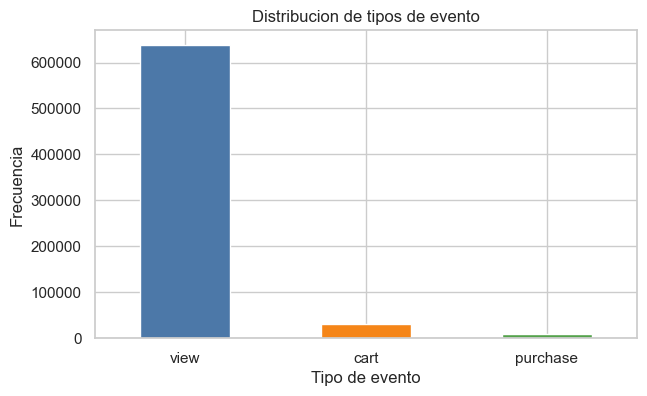

,proporcion
event_type,
view,0.942101
cart,0.044268
purchase,0.013631


In [7]:
event_counts = events["event_type"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
event_counts.plot(kind="bar", color=["#4c78a8", "#f58518", "#54a24b"])
plt.title("Distribucion de tipos de evento")
plt.xlabel("Tipo de evento")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.show()

display((event_counts / event_counts.sum()).rename("proporcion").to_frame())


La distribución de interacciones es principalmente view, mientras que cart y purchase aparecen con menor frecuencia.

Longitud de sesiones:

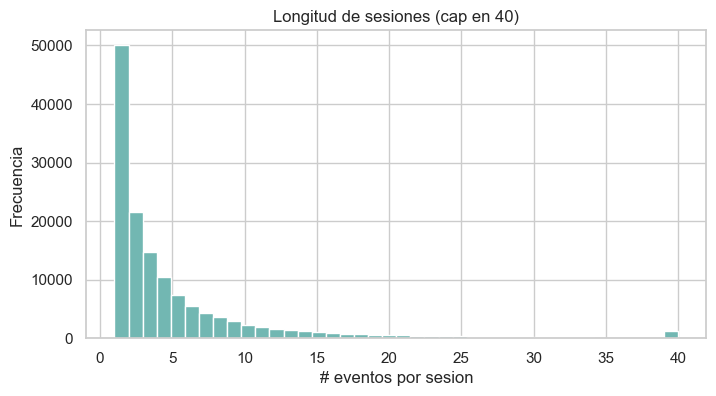

,valor
count,138013.000000
mean,4.910994
std,7.782321
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,316.000000


In [8]:
session_lengths_raw = events.groupby("user_session").size()

plt.figure(figsize=(8, 4))
session_lengths_raw.clip(upper=40).hist(bins=40, color="#72b7b2")
plt.title("Longitud de sesiones (cap en 40)")
plt.xlabel("# eventos por sesion")
plt.ylabel("Frecuencia")
plt.show()

display(session_lengths_raw.describe().to_frame("valor"))


La mayoria de las sesiones son cortas. El contexto reciente importa mucho.

Popularidad de productos:

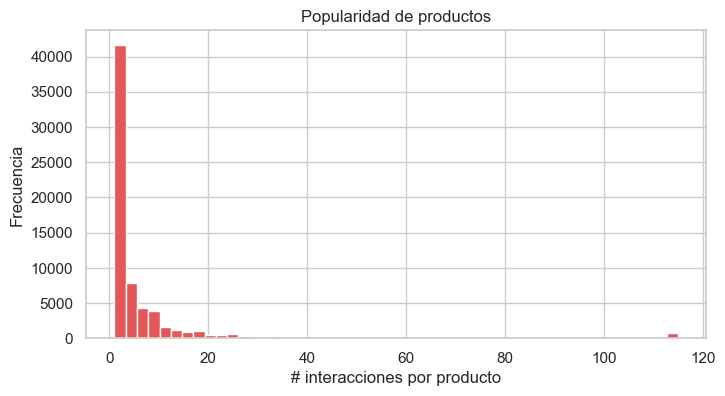

,product_id,interacciones
0,1005115,6703
1,1004856,6648
2,1004767,5642
3,4804056,3618
4,1005160,3344
5,1005105,3223
6,1004870,3073
7,1004833,3002
8,1004249,2926
9,1002544,2744


In [9]:
item_counts = events["product_id"].value_counts()

plt.figure(figsize=(8, 4))
item_counts.clip(upper=item_counts.quantile(0.99)).hist(bins=50, color="#e45756")
plt.title("Popularidad de productos")
plt.xlabel("# interacciones por producto")
plt.ylabel("Frecuencia")
plt.show()

display(item_counts.head(10).rename_axis("product_id").reset_index(name="interacciones"))


Pocos productos concentran muchas interacciones y una gran cantidad de items aparece pocas veces.

Sparsity del problema:

In [10]:
n_sessions = events["user_session"].nunique()
n_items = events["product_id"].nunique()
n_interactions = len(events)

sparsity = 1 - (n_interactions / (n_sessions * n_items))

print(f"Sesiones unicas: {n_sessions:,}")
print(f"Items unicos: {n_items:,}")
print(f"Interacciones: {n_interactions:,}")
print(f"Sparsity: {sparsity:.6f}")


Sesiones unicas: 138,013
Items unicos: 67,792
Interacciones: 677,781
Sparsity: 0.999928


El nivel de sparsity es alto.

Distribucion de precios:

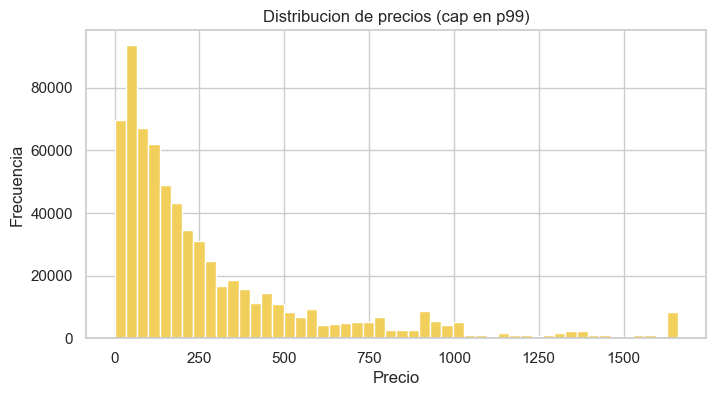

,valor
count,677781.000000
mean,291.755371
std,354.825531
min,0.000000
25%,69.169998
50%,164.699997
75%,360.339996
max,2574.070068


In [11]:
price_cap = events["price"].quantile(0.99)

plt.figure(figsize=(8, 4))
events["price"].clip(upper=price_cap).hist(bins=50, color="#f2cf5b")
plt.title("Distribucion de precios (cap en p99)")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

display(events["price"].describe().to_frame("valor"))


Los precios presentan dispersion y outliers. Viable para extensiones u otro tipo de señales.

Categorias mas frecuentes:

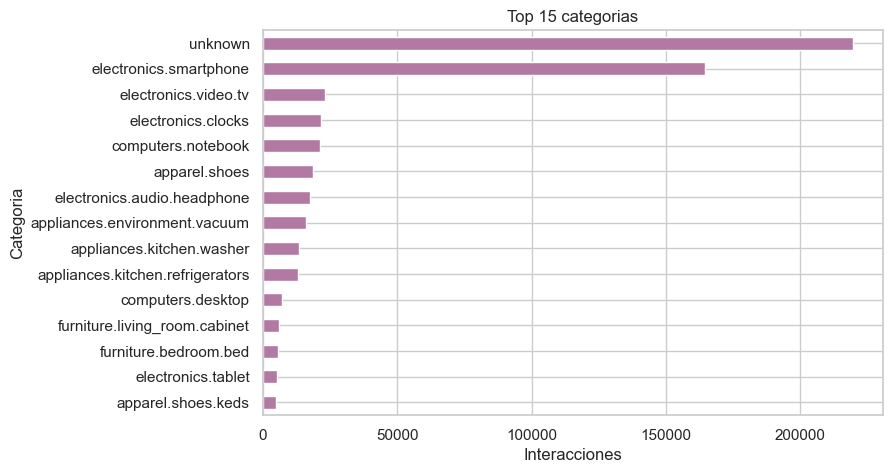

In [12]:
top_categories = (events["category_code"].fillna("unknown").value_counts().head(15).sort_values())

plt.figure(figsize=(8, 5))
top_categories.plot(kind="barh", color="#b279a2")
plt.title("Top 15 categorias")
plt.xlabel("Interacciones")
plt.ylabel("Categoria")
plt.show()


Marcas mas frecuentes:

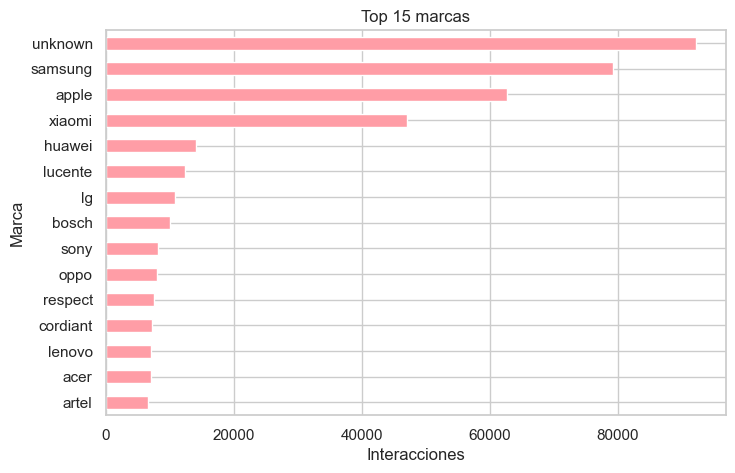

In [13]:
top_brands = (events["brand"].fillna("unknown").value_counts().head(15).sort_values())

plt.figure(figsize=(8, 5))
top_brands.plot(kind="barh", color="#ff9da6")
plt.title("Top 15 marcas")
plt.xlabel("Interacciones")
plt.ylabel("Marca")
plt.show()


Patron horario de actividad:

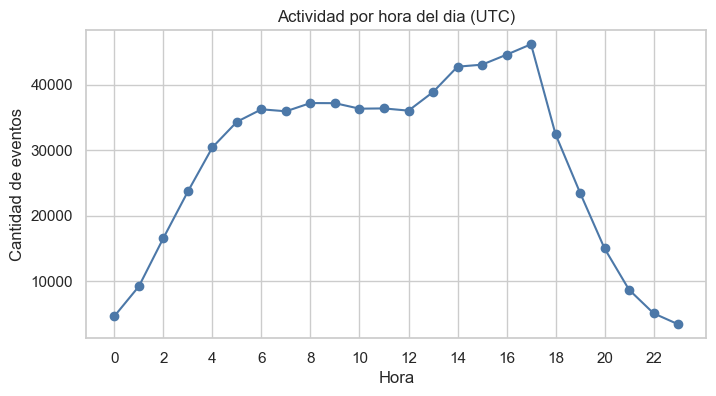

In [14]:
events["hour"] = events["event_time"].dt.hour
hour_counts = events["hour"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
hour_counts.plot(marker="o", color="#4c78a8")
plt.title("Actividad por hora del dia (UTC)")
plt.xlabel("Hora")
plt.ylabel("Cantidad de eventos")
plt.xticks(range(0, 24, 2))
plt.show()


Conversión a sesiones:

In [15]:
session_event_summary = (events.assign(value=1).pivot_table(index="user_session", columns="event_type", values="value", aggfunc="sum", fill_value=0,))

session_event_summary["has_cart"] = (session_event_summary.get("cart", 0) > 0).astype(int)
session_event_summary["has_purchase"] = (session_event_summary.get("purchase", 0) > 0).astype(int)

conversion_stats = pd.Series(
    {
        "sesiones_total": len(session_event_summary),
        "sesiones_con_cart": int(session_event_summary["has_cart"].sum()),
        "sesiones_con_purchase": int(session_event_summary["has_purchase"].sum()),
        "tasa_cart": float(session_event_summary["has_cart"].mean()),
        "tasa_purchase": float(session_event_summary["has_purchase"].mean()),
    }
)

display(conversion_stats.to_frame("valor"))


,valor
sesiones_total,138013.000000
sesiones_con_cart,17441.000000
sesiones_con_purchase,7791.000000
tasa_cart,0.126372
tasa_purchase,0.056451


Transiciones de eventos:

In [16]:
event_transitions = events[["user_session", "event_type"]].copy()
event_transitions["next_event"] = event_transitions.groupby("user_session")["event_type"].shift(-1)

transition_counts = (
    event_transitions.dropna(subset=["next_event"])
    .groupby(["event_type", "next_event"])
    .size()
    .sort_values(ascending=False)
    .head(10)
    .rename("conteo")
    .reset_index()
)

display(transition_counts)


,event_type,next_event,conteo
0,view,view,481954
1,view,cart,25703
2,cart,view,13646
3,cart,purchase,7533
4,purchase,view,5170
5,cart,cart,4078
6,view,purchase,1618
7,purchase,cart,45
8,purchase,purchase,21


Se nota la presencia de situaciones como view -> view o view -> purchase, hace sentido usar modelos que usen el orden de interaccion.

In [17]:
#Remueve repeticiones consecutivas del mismo producto dentro de una sesion.
def remove_consecutive_duplicates(seq):
    cleaned = []
    for item in seq:
        if not cleaned or cleaned[-1] != item:
            cleaned.append(item)
    return cleaned


def build_session_sequences(events_df):
    sessions = (
        events_df.groupby("user_session")
        .agg(
            #Secuencia ordenada de productos observados dentro de la sesion.
            items=("product_id", list),
            #Ultimo instante de la sesion, necesario para hacer el split temporal.
            end_time=("event_time", "max"),
            user_id=("user_id", "last"),
        )
        .reset_index()
    )

    #Se limpian repeticiones consecutivas y se calcula la longitud final de cada sesion.
    sessions["items"] = sessions["items"].apply(remove_consecutive_duplicates)
    sessions["session_len"] = sessions["items"].apply(len)
    return sessions


#Construye las secuencias base por sesion. El filtrado final se hara despues del split temporal
#para que el soporte de items dependa solo de train y no use informacion futura.
session_sequences = build_session_sequences(events)

print(f"Sesiones crudas: {len(session_sequences):,}")
print(f"Longitud promedio cruda: {session_sequences['session_len'].mean():.2f}")
print(f"Longitud maxima cruda: {session_sequences['session_len'].max()}")
display(session_sequences.head())


Sesiones crudas: 138,013
Longitud promedio cruda: 3.39
Longitud maxima cruda: 251


,user_session,items,end_time,user_id,session_len
0,000052ae-8b53-42a9-a7b5-b91e0815c3d3,[58300004],2019-11-20 11:11:41+00:00,573882848,1
1,00005795-7758-472e-a2d9-d042a408d714,"[23900200, 23301148, 23300426, 23300474, 23300...",2019-11-23 07:56:29+00:00,512677924,6
2,0000636a-8d84-48c1-9b9a-006e614bd16d,"[23301443, 23300983]",2019-11-14 14:59:00+00:00,544436397,2
3,00018dc2-16ee-4a4c-8074-9fb126c4b97b,[10503183],2019-11-19 16:54:35+00:00,573568101,1
4,0002b68a-8967-4569-8149-826c4006fc3a,"[3100941, 3100933, 3100847, 3100491, 3100583, ...",2019-11-19 07:35:31+00:00,514731583,21


Split temporal de sesiones

In [18]:
train_sessions_raw, val_sessions_raw, test_sessions_raw = SepararSesionesPorVentanasDeTiempo(
    session_sequences,
    validation_days=VALIDATION_DAYS,
    test_days=TEST_DAYS,
)

train_sessions, val_sessions, test_sessions = FiltrarItemsTrainYProyectarSplits(
    train_sessions_raw,
    val_sessions_raw,
    test_sessions_raw,
    min_session_len=MIN_SESSION_LEN,
    min_item_support=MIN_ITEM_SUPPORT,
)


def split_summary_df(name, df):
    return {"split": name,
        "sesiones": len(df),
        "interacciones": int(df["session_len"].sum()),
        "items_unicos": len({item for seq in df["items"] for item in seq}),
        "inicio": df["end_time"].min(),
        "fin": df["end_time"].max(),
    }


#Resume tamaño y rango temporal de cada particion para verificar que el split quedo coherente.
split_summary = pd.DataFrame([split_summary_df("train", train_sessions), split_summary_df("validation", val_sessions), split_summary_df("test", test_sessions),])

display(split_summary)


,split,sesiones,interacciones,items_unicos,inicio,fin
0,train,48661,255659,12519,2019-11-01 00:15:29+00:00,2019-11-24 23:55:37+00:00
1,validation,4135,18836,5194,2019-11-25 00:02:43+00:00,2019-11-27 23:49:46+00:00
2,test,4423,19330,5032,2019-11-28 00:02:38+00:00,2019-11-30 23:57:02+00:00


### 2. Baselines y evaluacion

Se usan metricas como `Recall@K`, `NDCG@K` y `MAP@K`.

In [19]:
def build_eval_cases(session_df, max_session_len=20):
    eval_cases = session_df.copy()
    eval_cases["prefix_items"] = eval_cases["items"].apply(lambda seq: seq[:-1][-max_session_len:])
    eval_cases["target_item"] = eval_cases["items"].apply(lambda seq: seq[-1])
    eval_cases["seen_items"] = eval_cases["prefix_items"].apply(set)
    eval_cases = eval_cases[eval_cases["prefix_items"].apply(len) > 0].reset_index(drop=True)
    return eval_cases


def recall_at_k(recommended, relevant, k):
    hits = sum(1 for item in recommended[:k] if item in relevant)
    return hits / len(relevant) if relevant else 0.0


def dcg_at_k(relevances, k):
    relevances = np.array(relevances[:k], dtype=float)
    if len(relevances) == 0:
        return 0.0
    discounts = np.log2(np.arange(2, len(relevances) + 2))
    return float((relevances / discounts).sum())


def ndcg_at_k(recommended, relevant, k):
    relevances = [1 if item in relevant else 0 for item in recommended[:k]]
    ideal = sorted(relevances, reverse=True)
    ideal_dcg = dcg_at_k(ideal, k)
    if ideal_dcg == 0:
        return 0.0
    return dcg_at_k(relevances, k) / ideal_dcg


def average_precision_at_k(recommended, relevant, k):
    hits = 0
    precision_sum = 0.0

    for idx, item in enumerate(recommended[:k], start=1):
        if item in relevant:
            hits += 1
            precision_sum += hits / idx

    denom = min(len(relevant), k)
    return precision_sum / denom if denom > 0 else 0.0


Construccion para recomendacion

In [20]:
train_eval = build_eval_cases(train_sessions, max_session_len=MAX_SESSION_LEN)
val_eval = build_eval_cases(val_sessions, max_session_len=MAX_SESSION_LEN)
test_eval = build_eval_cases(test_sessions, max_session_len=MAX_SESSION_LEN)

train_item_popularity = Counter(item for seq in train_sessions["items"] for item in seq)
popular_items = [item for item, _ in train_item_popularity.most_common()]
candidate_items = np.array(popular_items, dtype=np.int64)
candidate_items_set = set(candidate_items.tolist())

print(f"Casos de train: {len(train_eval):,}")
print(f"Casos de validation: {len(val_eval):,}")
print(f"Casos de test: {len(test_eval):,}")
print(f"Catalogo util: {len(candidate_items):,} items")


Casos de train: 48,661
Casos de validation: 4,135
Casos de test: 4,423
Catalogo util: 12,519 items


Baseline random:

In [21]:
def recommend_random(prefix_items, k=10, seen_items=None, seed=42):
    seen_items = set(prefix_items) if seen_items is None else set(seen_items)
    available = [item for item in candidate_items if item not in seen_items]
    if not available:
        return []

    target_k = min(k, len(available))
    rng = np.random.default_rng(seed + len(prefix_items))
    sampled = rng.choice(np.array(available, dtype=np.int64), size=target_k, replace=False)
    return sampled.tolist()


Baseline most popular:

In [22]:
def recommend_most_popular(prefix_items, k=10, seen_items=None):
    seen_items = set(prefix_items) if seen_items is None else set(seen_items)
    recs = []

    for item in popular_items:
        if item in seen_items:
            continue
        recs.append(item)
        if len(recs) == k:
            break

    return recs


Baseline item-based (Item-KNN simple):

In [23]:
#Cuenta cuantas sesiones contienen cada producto.
item_support = Counter()

#Cuantas veces dos productos aparecen cerca dentro de una misma sesion.
cooccurrence = defaultdict(Counter)

for seq in train_sessions["items"]:
    #Se eliminan repetidos dentro de la misma sesion para no inflar las concurrencias.
    unique_seq = list(dict.fromkeys(seq))

    for item in unique_seq:
        item_support[item] += 1

    for i, item in enumerate(unique_seq):
        #Ventana local alrededor del item para capturar contexto cercano.
        left = max(0, i - 3)
        right = min(len(unique_seq), i + 4)
        for j in range(left, right):
            if i == j:
                continue
            other = unique_seq[j]
            cooccurrence[item][other] += 1


item_neighbors = {}
for item, neighbors in cooccurrence.items():
    scored = []
    for other, count in neighbors.items():
        #Normaliza la coocurrencia para no favorecer solo a los items mas populares.
        score = count / math.sqrt(item_support[item] * item_support[other])
        scored.append((other, score))

    #Se guardan solo los vecinos mas similares de cada item.
    scored = sorted(scored, key=lambda x: x[1], reverse=True)[:100]
    item_neighbors[item] = scored


def recommend_item_knn(prefix_items, k=10, seen_items=None, last_n=5):
    seen_items = set(prefix_items) if seen_items is None else set(seen_items)

    #Solo usa los ultimos items de la sesion, porque representan mejor la intencion reciente.
    history = prefix_items[-last_n:]
    scores = Counter()

    for rank, item in enumerate(reversed(history), start=1):
        #Los items mas recientes reciben mayor peso.
        weight = 1 / rank
        for other, sim in item_neighbors.get(item, []):
            if other in seen_items:
                continue
            scores[other] += sim * weight

    recs = [item for item, _ in scores.most_common(k)]

    #Si no alcanza a completar k recomendaciones, rellena con items populares no vistos.
    if len(recs) < k:
        for item in popular_items:
            if item in seen_items or item in recs:
                continue
            recs.append(item)
            if len(recs) == k:
                break

    return recs


Este `Item-KNN` construye similitud entre productos a partir de concurrencias dentro de la misma sesión. Incorpora estructura local y contexto reciente.

Evaluacion de baselines

In [24]:
def evaluate_recommender(recommender_fn, eval_cases, ks=(5, 10, 20), label="model"):
    rows = []
    max_k = max(ks)

    for k in ks:
        recall_scores = []
        ndcg_scores = []
        map_scores = []

        for row in eval_cases.itertuples(index=False):
            relevant = {row.target_item}
            recs = recommender_fn(row.prefix_items, k=max_k, seen_items=row.seen_items)

            recall_scores.append(recall_at_k(recs, relevant, k))
            ndcg_scores.append(ndcg_at_k(recs, relevant, k))
            map_scores.append(average_precision_at_k(recs, relevant, k))

        rows.append(
            {
                "modelo": label,
                "k": k,
                "recall": float(np.mean(recall_scores)) if recall_scores else 0.0,
                "ndcg": float(np.mean(ndcg_scores)) if ndcg_scores else 0.0,
                "map": float(np.mean(map_scores)) if map_scores else 0.0,
            }
        )

    return pd.DataFrame(rows)


baseline_results_val = pd.concat(
    [
        evaluate_recommender(recommend_random, val_eval, ks=TOP_KS, label="random"),
        evaluate_recommender(recommend_most_popular, val_eval, ks=TOP_KS, label="most_popular"),
        evaluate_recommender(recommend_item_knn, val_eval, ks=TOP_KS, label="item_knn"),
    ],
    ignore_index=True,
)
baseline_results_test = pd.concat(
    [
        evaluate_recommender(recommend_random, test_eval, ks=TOP_KS, label="random"),
        evaluate_recommender(recommend_most_popular, test_eval, ks=TOP_KS, label="most_popular"),
        evaluate_recommender(recommend_item_knn, test_eval, ks=TOP_KS, label="item_knn"),
    ],
    ignore_index=True,
)

print("Validation")
display(baseline_results_val.sort_values(["k", "recall"], ascending=[True, False]))

print("Test")
display(baseline_results_test.sort_values(["k", "recall"], ascending=[True, False]))


Validation


,modelo,k,recall,ndcg,map
6,item_knn,5,0.181137,0.122847,0.103700
3,most_popular,5,0.027570,0.017528,0.014236
0,random,5,0.000967,0.000551,0.000411
7,item_knn,10,0.261185,0.148805,0.114456
4,most_popular,10,0.051270,0.025031,0.017241
1,random,10,0.001209,0.000624,0.000438
8,item_knn,20,0.339057,0.168654,0.119989
5,most_popular,20,0.078597,0.031872,0.019082
2,random,20,0.001693,0.000737,0.000464


Test


,modelo,k,recall,ndcg,map
6,item_knn,5,0.177707,0.119955,0.100957
3,most_popular,5,0.028487,0.017368,0.013743
0,random,5,0.000226,0.000226,0.000226
7,item_knn,10,0.255031,0.144943,0.111257
4,most_popular,10,0.049288,0.023906,0.016331
1,random,10,0.000452,0.000297,0.000254
8,item_knn,20,0.335067,0.165375,0.116971
5,most_popular,20,0.078680,0.031365,0.018393
2,random,20,0.000678,0.000357,0.000272


Item-KNN supera con claridad a Most Popular y Random en Recall, NDCG y MAP, tanto en validación como en test. Esto sugiere que la señal local de coocurrencia dentro de la sesión es muy fuerte y ya captura buena parte de la intención inmediata del usuario.

### 3. Comparacion final de baselines

,modelo,k,recall,ndcg,map,split
15,item_knn,5,0.177707,0.119955,0.100957,test
12,most_popular,5,0.028487,0.017368,0.013743,test
9,random,5,0.000226,0.000226,0.000226,test
16,item_knn,10,0.255031,0.144943,0.111257,test
13,most_popular,10,0.049288,0.023906,0.016331,test
10,random,10,0.000452,0.000297,0.000254,test
17,item_knn,20,0.335067,0.165375,0.116971,test
14,most_popular,20,0.078680,0.031365,0.018393,test
11,random,20,0.000678,0.000357,0.000272,test
6,item_knn,5,0.181137,0.122847,0.103700,validation


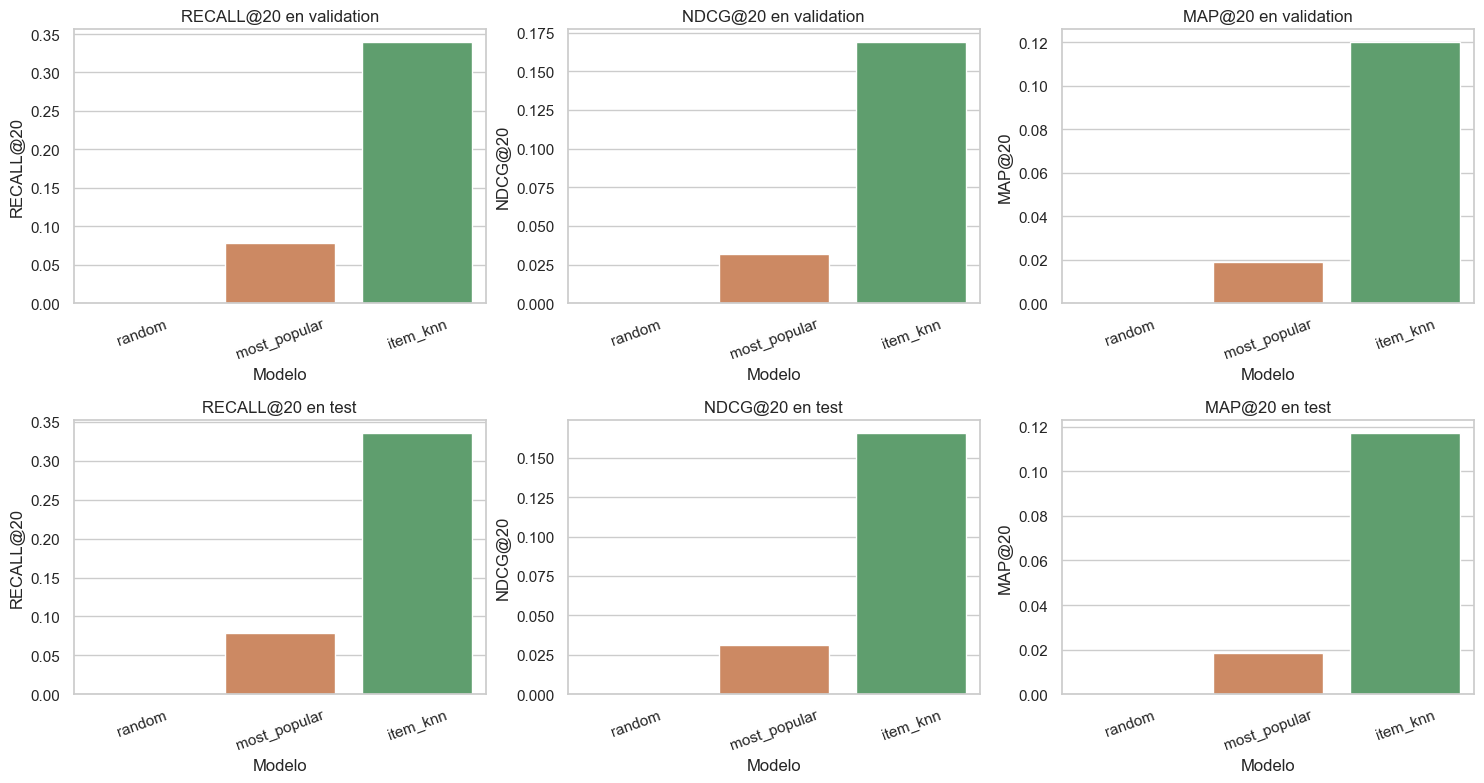

In [25]:
comparison_df = pd.concat([baseline_results_val.assign(split="validation"), baseline_results_test.assign(split="test"),], ignore_index=True,)

display(comparison_df.sort_values(["split", "k", "recall"], ascending=[True, True, False]))

plot_df = comparison_df[comparison_df["k"] == 20].copy()
metrics = ["recall", "ndcg", "map"]
splits = ["validation", "test"]

fig, axes = plt.subplots(len(splits), len(metrics), figsize=(15, 8))

for row_idx, split in enumerate(splits):
    split_df = plot_df[plot_df["split"] == split].copy()

    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        sns.barplot(
            data=split_df,
            x="modelo",
            y=metric,
            hue="modelo",
            palette="deep",
            legend=False,
            ax=ax,
        )
        ax.set_title(f"{metric.upper()}@20 en {split}")
        ax.set_xlabel("Modelo")
        ax.set_ylabel(f"{metric.upper()}@20")
        ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


### 4. Modelos secuenciales neurales

Se prueban dos modelos secuenciales neuronales: `GRU4Rec` y `SASRec`.

In [26]:
gru4rec_recommender, gru4rec_history = EntrenarGru4Rec(
    train_sessions,
    max_session_len=MAX_SESSION_LEN,
    embedding_dim=64,
    hidden_dim=96,
    dropout=0.2,
    epochs=2,
    batch_size=512,
    learning_rate=1e-3,
    max_train_examples=120_000,
    usar_todos_los_prefijos=True,
    seed=RANDOM_STATE,
    device="cpu",
    verbose=True,
)

sasrec_recommender, sasrec_history = EntrenarSasRec(
    train_sessions,
    max_session_len=MAX_SESSION_LEN,
    embedding_dim=64,
    num_heads=2,
    num_layers=1,
    dropout=0.2,
    epochs=2,
    batch_size=256,
    learning_rate=1e-3,
    max_train_examples=80_000,
    usar_todos_los_prefijos=True,
    seed=RANDOM_STATE,
    device="cpu",
    verbose=True,
)

display(pd.DataFrame(gru4rec_history))
display(pd.DataFrame(sasrec_history))


Epoch 1/2 - loss: 8.8472
Epoch 2/2 - loss: 8.1795
Epoch 1/2 - loss: 8.9352
Epoch 2/2 - loss: 8.3738


,epoch,loss
0,1,8.847215
1,2,8.179469


,epoch,loss
0,1,8.935176
1,2,8.373843


Validation


,modelo,k,recall,ndcg,map
6,item_knn,5,0.181137,0.122847,0.103700
9,gru4rec,5,0.066264,0.045538,0.038694
12,sasrec,5,0.047642,0.032486,0.027517
3,most_popular,5,0.027570,0.017528,0.014236
0,random,5,0.000967,0.000551,0.000411
7,item_knn,10,0.261185,0.148805,0.114456
10,gru4rec,10,0.095284,0.054937,0.042584
13,sasrec,10,0.071100,0.040096,0.030670
4,most_popular,10,0.051270,0.025031,0.017241
1,random,10,0.001209,0.000624,0.000438


Test


,modelo,k,recall,ndcg,map
6,item_knn,5,0.177707,0.119955,0.100957
9,gru4rec,5,0.057653,0.040388,0.034728
12,sasrec,5,0.042731,0.029386,0.024991
3,most_popular,5,0.028487,0.017368,0.013743
0,random,5,0.000226,0.000226,0.000226
7,item_knn,10,0.255031,0.144943,0.111257
10,gru4rec,10,0.085915,0.049505,0.038475
13,sasrec,10,0.068279,0.037638,0.028391
4,most_popular,10,0.049288,0.023906,0.016331
1,random,10,0.000452,0.000297,0.000254


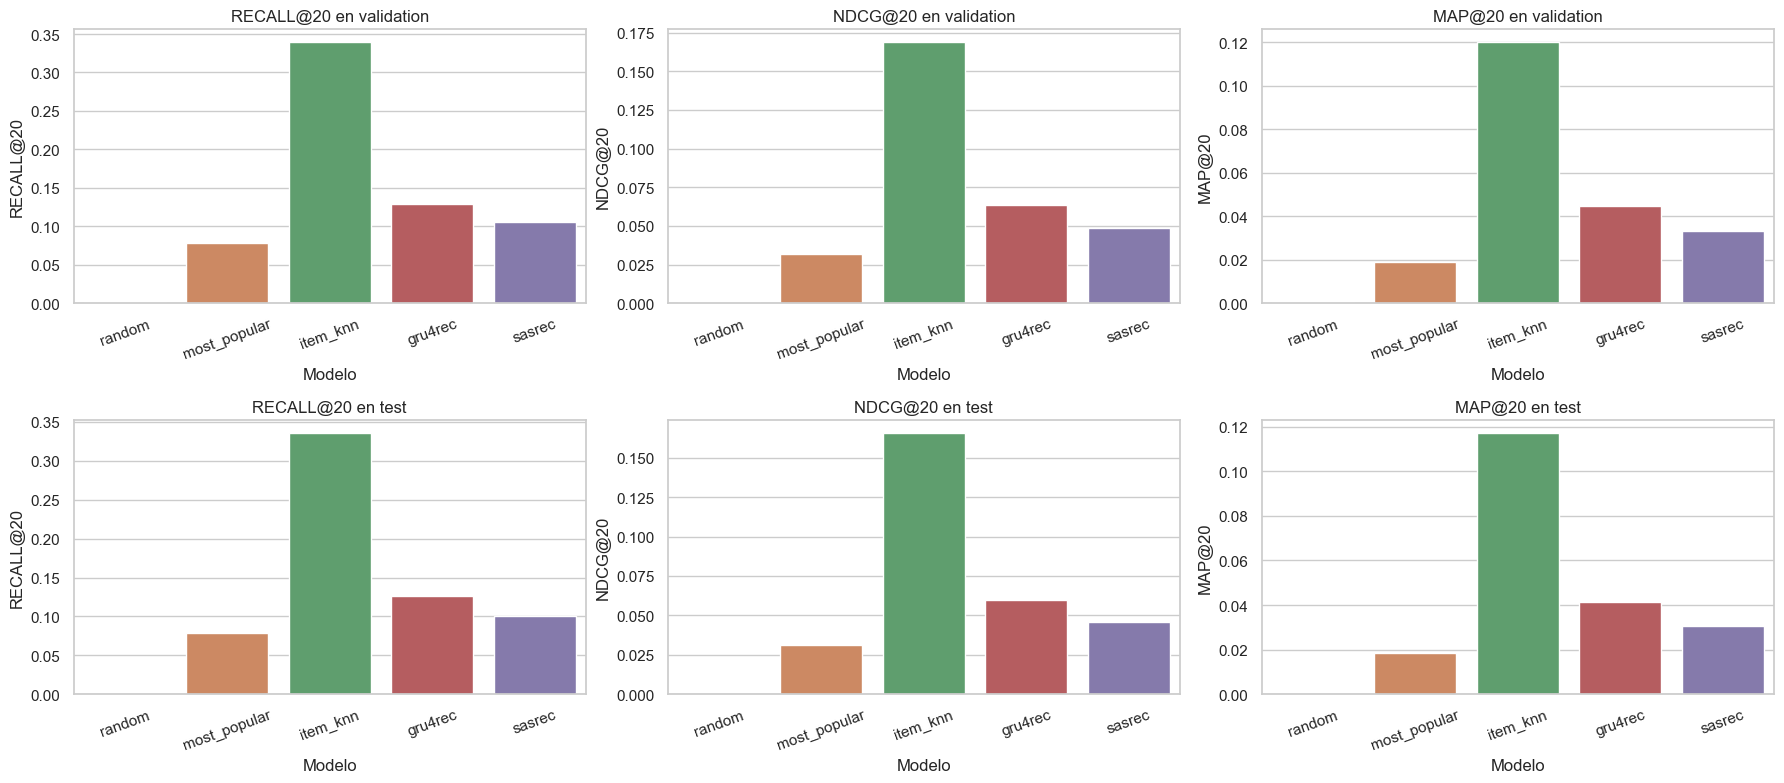

In [27]:
neural_results_val = pd.concat(
    [
        evaluate_recommender(gru4rec_recommender.Recomendar, val_eval, ks=TOP_KS, label="gru4rec"),
        evaluate_recommender(sasrec_recommender.Recomendar, val_eval, ks=TOP_KS, label="sasrec"),
    ],
    ignore_index=True,
)
neural_results_test = pd.concat(
    [
        evaluate_recommender(gru4rec_recommender.Recomendar, test_eval, ks=TOP_KS, label="gru4rec"),
        evaluate_recommender(sasrec_recommender.Recomendar, test_eval, ks=TOP_KS, label="sasrec"),
    ],
    ignore_index=True,
)

all_results_val = pd.concat([baseline_results_val, neural_results_val], ignore_index=True)
all_results_test = pd.concat([baseline_results_test, neural_results_test], ignore_index=True)
all_results = pd.concat(
    [
        all_results_val.assign(split="validation"),
        all_results_test.assign(split="test"),
    ],
    ignore_index=True,
)

print("Validation")
display(all_results_val.sort_values(["k", "recall"], ascending=[True, False]))

print("Test")
display(all_results_test.sort_values(["k", "recall"], ascending=[True, False]))

plot_df = all_results[all_results["k"] == 20].copy()
metrics = ["recall", "ndcg", "map"]
splits = ["validation", "test"]

fig, axes = plt.subplots(len(splits), len(metrics), figsize=(18, 8))

for row_idx, split in enumerate(splits):
    split_df = plot_df[plot_df["split"] == split].copy()

    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        sns.barplot(data=split_df, x="modelo", y=metric, hue="modelo", palette="deep", legend=False, ax=ax,)
        ax.set_title(f"{metric.upper()}@20 en {split}")
        ax.set_xlabel("Modelo")
        ax.set_ylabel(f"{metric.upper()}@20")
        ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


En esta corrida, los modelos neuronales sí aprenden patrones útiles, pero todavía quedan por debajo de Item-KNN. GRU4Rec suele rendir mejor que SASRec en este setup.

### 5. Reglas secuenciales e hibridos

`Item-KNN` es un baseline muy fuerte, se prueban `Sequential Rules` como modelo secuencial basado en transiciones y una mezcla hibrida que combine la señal local de KNN con reglas o con `GRU4Rec`.

In [28]:
item_knn_recommender = ConstruirItemKnnRecomendador(train_sessions, max_neighbors=100, window_size=3, last_n=5,)

seq_rules_recommender = ConstruirSequentialRulesRecomendador(train_sessions, max_steps=10, max_rules_per_item=200, last_n=5,)

hybrid_knn_gru_recommender = ConstruirRecomendadorHibrido([("item_knn", item_knn_recommender, 0.75), ("gru4rec", gru4rec_recommender, 0.25),], popular_items=item_knn_recommender.popular_items,)

hybrid_knn_rules_recommender = ConstruirRecomendadorHibrido([("item_knn", item_knn_recommender, 0.60), ("seq_rules", seq_rules_recommender, 0.40),], popular_items=item_knn_recommender.popular_items,)


In [29]:
experiment_results_val = pd.concat(
    [
        evaluate_recommender(item_knn_recommender.Recomendar, val_eval, ks=TOP_KS, label="item_knn_mod"),
        evaluate_recommender(seq_rules_recommender.Recomendar, val_eval, ks=TOP_KS, label="seq_rules"),
        evaluate_recommender(hybrid_knn_gru_recommender.Recomendar, val_eval, ks=TOP_KS, label="hybrid_knn_gru"),
        evaluate_recommender(hybrid_knn_rules_recommender.Recomendar, val_eval, ks=TOP_KS, label="hybrid_knn_rules"),
    ],
    ignore_index=True,
)

experiment_results_test = pd.concat(
    [
        evaluate_recommender(item_knn_recommender.Recomendar, test_eval, ks=TOP_KS, label="item_knn_mod"),
        evaluate_recommender(seq_rules_recommender.Recomendar, test_eval, ks=TOP_KS, label="seq_rules"),
        evaluate_recommender(hybrid_knn_gru_recommender.Recomendar, test_eval, ks=TOP_KS, label="hybrid_knn_gru"),
        evaluate_recommender(hybrid_knn_rules_recommender.Recomendar, test_eval, ks=TOP_KS, label="hybrid_knn_rules"),
    ],
    ignore_index=True,
)

print("Validation")
display(experiment_results_val.sort_values(["k", "recall"], ascending=[True, False]))

print("Test")
display(experiment_results_test.sort_values(["k", "recall"], ascending=[True, False]))


Validation


,modelo,k,recall,ndcg,map
9,hybrid_knn_rules,5,0.185006,0.124371,0.104526
6,hybrid_knn_gru,5,0.182830,0.124343,0.105131
0,item_knn_mod,5,0.181137,0.122847,0.103700
3,seq_rules,5,0.166626,0.113563,0.096187
10,hybrid_knn_rules,10,0.266989,0.150841,0.115426
1,item_knn_mod,10,0.261185,0.148805,0.114456
7,hybrid_knn_gru,10,0.260701,0.149479,0.115475
4,seq_rules,10,0.244498,0.138627,0.106465
11,hybrid_knn_rules,20,0.353325,0.172746,0.121480
8,hybrid_knn_gru,20,0.339541,0.169578,0.121081


Test


,modelo,k,recall,ndcg,map
9,hybrid_knn_rules,5,0.182908,0.122081,0.102076
6,hybrid_knn_gru,5,0.179516,0.120881,0.101613
0,item_knn_mod,5,0.177707,0.119955,0.100957
3,seq_rules,5,0.168438,0.110629,0.091702
10,hybrid_knn_rules,10,0.260457,0.147105,0.112368
1,item_knn_mod,10,0.255031,0.144943,0.111257
7,hybrid_knn_gru,10,0.252996,0.144618,0.111392
4,seq_rules,10,0.238074,0.133202,0.101053
11,hybrid_knn_rules,20,0.345015,0.168435,0.118196
2,item_knn_mod,20,0.335067,0.165375,0.116971


,modelo,k,recall,ndcg,map,split
51,hybrid_knn_rules,5,0.182908,0.122081,0.102076,test
48,hybrid_knn_gru,5,0.179516,0.120881,0.101613,test
21,item_knn,5,0.177707,0.119955,0.100957,test
42,item_knn_mod,5,0.177707,0.119955,0.100957,test
45,seq_rules,5,0.168438,0.110629,0.091702,test
24,gru4rec,5,0.057653,0.040388,0.034728,test
27,sasrec,5,0.042731,0.029386,0.024991,test
18,most_popular,5,0.028487,0.017368,0.013743,test
15,random,5,0.000226,0.000226,0.000226,test
52,hybrid_knn_rules,10,0.260457,0.147105,0.112368,test


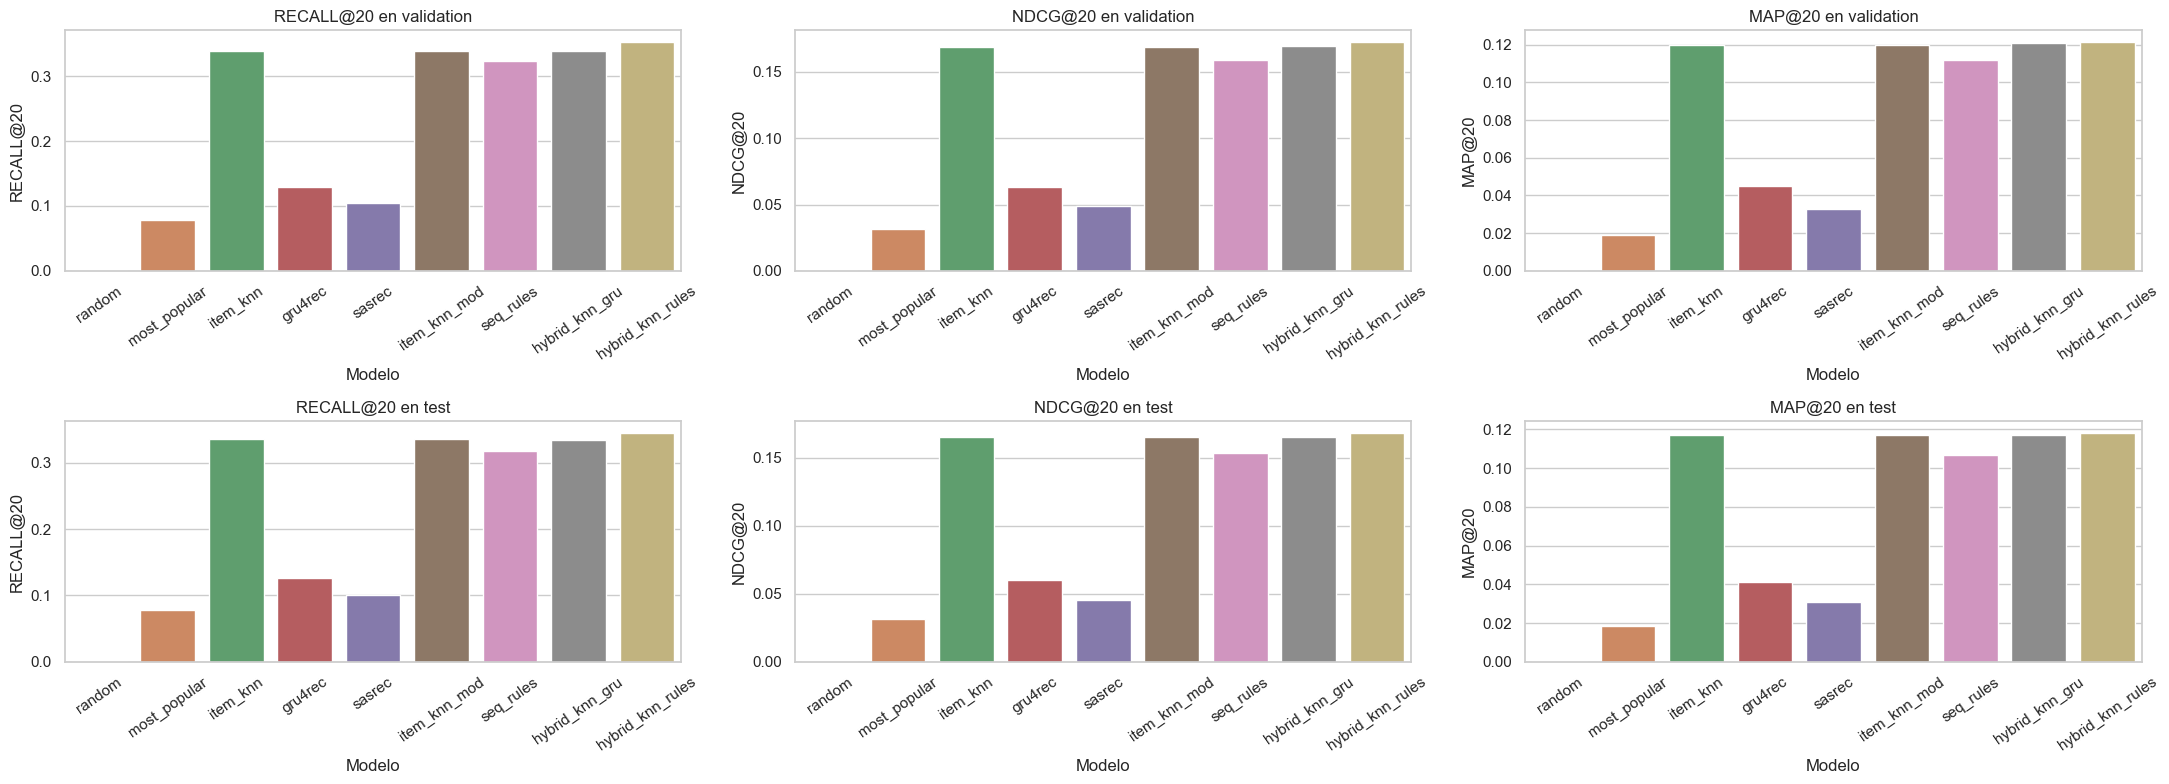

In [30]:
all_experiment_results = pd.concat(
    [
        all_results_val.assign(split="validation"),
        all_results_test.assign(split="test"),
        experiment_results_val.assign(split="validation"),
        experiment_results_test.assign(split="test"),
    ],
    ignore_index=True,
)

display(all_experiment_results.sort_values(["split", "k", "recall"], ascending=[True, True, False]))

plot_df = all_experiment_results[all_experiment_results["k"] == 20].copy()
metrics = ["recall", "ndcg", "map"]
splits = ["validation", "test"]

fig, axes = plt.subplots(len(splits), len(metrics), figsize=(22, 8))

for row_idx, split in enumerate(splits):
    split_df = plot_df[plot_df["split"] == split].copy()

    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        sns.barplot(data=split_df, x="modelo", y=metric, hue="modelo", palette="deep", legend=False, ax=ax,)
        ax.set_title(f"{metric.upper()}@20 en {split}")
        ax.set_xlabel("Modelo")
        ax.set_ylabel(f"{metric.upper()}@20")
        ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()


Las reglas secuenciales puras ya son bastante competitivas. Lo más interesante es que el híbrido captura una mejora adicional. Si `hybrid_knn_rules` queda por encima de `item_knn_mod`, resulta lógico combinar vecindad local con transiciones ordenadas, ya que aporta una señal complementaria útil para este dataset y en general para el problema de recomendación.

### 6. Metadatos de producto

Aquí se usan señales simples del catálogo, construidas solo con eventos de train como categoría, marca y precio. La idea es rerankear sus candidatos para ver si los metadatos aportan información adicional.

In [31]:
train_session_ids = set(train_sessions["user_session"])
train_events = events[events["user_session"].isin(train_session_ids)].copy()
item_metadata = ConstruirMetadatosItems(train_events)

item_knn_meta_recommender = ConstruirRecomendadorRerankMetadatos(
    item_knn_recommender,
    item_metadata,
    popular_items=item_knn_recommender.popular_items,
    candidate_k=100,
    weight_base=0.70,
    weight_category=0.15,
    weight_brand=0.05,
    weight_price=0.10,
)

hybrid_knn_rules_meta_recommender = ConstruirRecomendadorRerankMetadatos(
    hybrid_knn_rules_recommender,
    item_metadata,
    popular_items=item_knn_recommender.popular_items,
    candidate_k=100,
    weight_base=0.70,
    weight_category=0.15,
    weight_brand=0.05,
    weight_price=0.10,
)

display(item_metadata.head())


,product_id,category_code,brand,price,log_price,category_root
0,1000978,electronics.smartphone,samsung,300.910004,5.710129,electronics
1,1001588,electronics.smartphone,meizu,127.750000,4.857872,electronics
2,1001618,electronics.smartphone,apple,501.660004,6.219914,electronics
3,1002062,electronics.smartphone,samsung,107.589996,4.687579,electronics
4,1002098,electronics.smartphone,samsung,370.640015,5.917926,electronics


In [32]:
metadata_results_val = pd.concat(
    [
        evaluate_recommender(item_knn_meta_recommender.Recomendar, val_eval, ks=TOP_KS, label="item_knn_meta"),
        evaluate_recommender(hybrid_knn_rules_meta_recommender.Recomendar, val_eval, ks=TOP_KS, label="hybrid_knn_rules_meta"),
    ],
    ignore_index=True,
)

metadata_results_test = pd.concat(
    [
        evaluate_recommender(item_knn_meta_recommender.Recomendar, test_eval, ks=TOP_KS, label="item_knn_meta"),
        evaluate_recommender(hybrid_knn_rules_meta_recommender.Recomendar, test_eval, ks=TOP_KS, label="hybrid_knn_rules_meta"),
    ],
    ignore_index=True,
)

print("Validation")
display(metadata_results_val.sort_values(["k", "recall"], ascending=[True, False]))

print("Test")
display(metadata_results_test.sort_values(["k", "recall"], ascending=[True, False]))


Validation


,modelo,k,recall,ndcg,map
3,hybrid_knn_rules_meta,5,0.193712,0.130488,0.109730
0,item_knn_meta,5,0.191052,0.128271,0.107658
4,hybrid_knn_rules_meta,10,0.274486,0.156687,0.120588
1,item_knn_meta,10,0.271826,0.154514,0.118558
5,hybrid_knn_rules_meta,20,0.360822,0.178531,0.126592
2,item_knn_meta,20,0.351632,0.174480,0.123929


Test


,modelo,k,recall,ndcg,map
3,hybrid_knn_rules_meta,5,0.189238,0.124780,0.103599
0,item_knn_meta,5,0.186525,0.123091,0.102287
4,hybrid_knn_rules_meta,10,0.270179,0.150867,0.114315
1,item_knn_meta,10,0.268596,0.149454,0.113068
5,hybrid_knn_rules_meta,20,0.352024,0.171679,0.120093
2,item_knn_meta,20,0.342076,0.168141,0.118255


,modelo,k,recall,ndcg,map,split
63,hybrid_knn_rules_meta,5,0.189238,0.124780,0.103599,test
60,item_knn_meta,5,0.186525,0.123091,0.102287,test
51,hybrid_knn_rules,5,0.182908,0.122081,0.102076,test
48,hybrid_knn_gru,5,0.179516,0.120881,0.101613,test
21,item_knn,5,0.177707,0.119955,0.100957,test
...,...,...,...,...,...,...
35,seq_rules,20,0.324305,0.158837,0.112029,validation
11,gru4rec,20,0.129383,0.063517,0.044915,validation
14,sasrec,20,0.105200,0.048706,0.033025,validation
5,most_popular,20,0.078597,0.031872,0.019082,validation


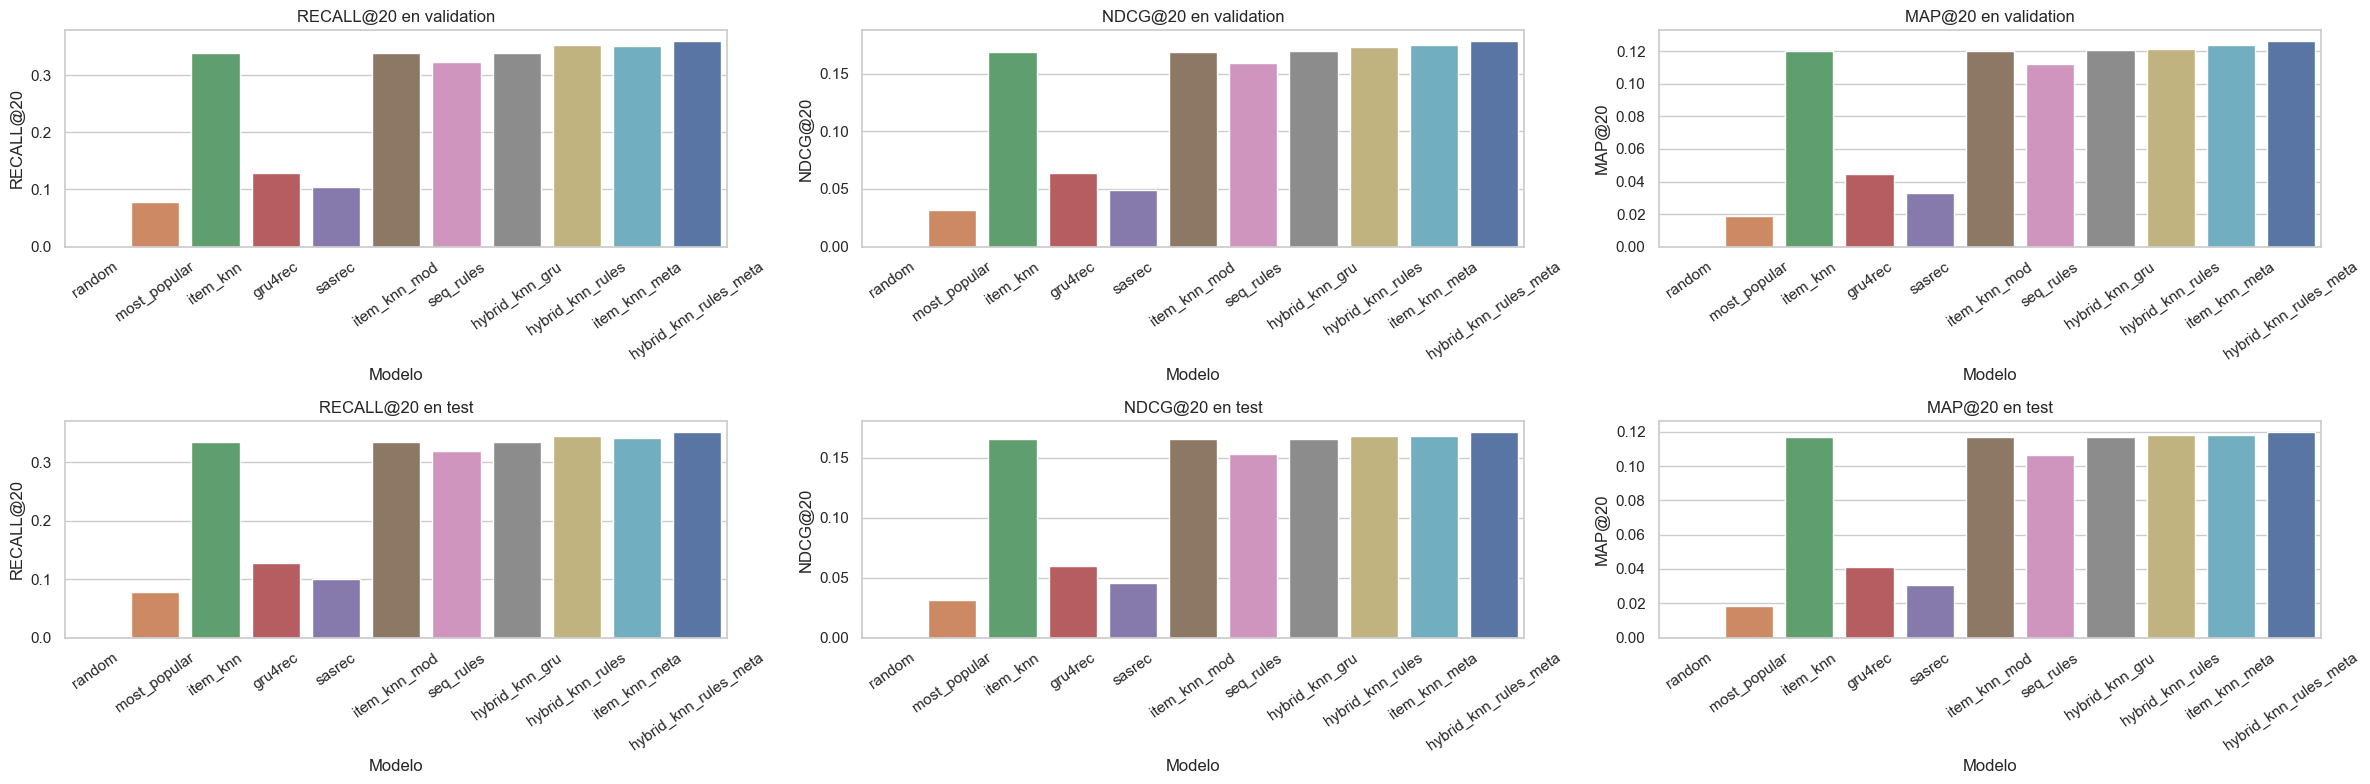

In [33]:
all_metadata_results = pd.concat(
    [
        all_experiment_results,
        metadata_results_val.assign(split="validation"),
        metadata_results_test.assign(split="test"),
    ],
    ignore_index=True,
)

display(all_metadata_results.sort_values(["split", "k", "recall"], ascending=[True, True, False]))

plot_df = all_metadata_results[all_metadata_results["k"] == 20].copy()
metrics = ["recall", "ndcg", "map"]
splits = ["validation", "test"]

fig, axes = plt.subplots(len(splits), len(metrics), figsize=(24, 8))

for row_idx, split in enumerate(splits):
    split_df = plot_df[plot_df["split"] == split].copy()

    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        sns.barplot(data=split_df, x="modelo", y=metric, hue="modelo", palette="deep", legend=False, ax=ax,)
        ax.set_title(f"{metric.upper()}@20 en {split}")
        ax.set_xlabel("Modelo")
        ax.set_ylabel(f"{metric.upper()}@20")
        ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()


En esta prueba sí hay mejora con metadatos adicionales. Tanto `item_knn_meta` como `hybrid_knn_rules_meta` superan a sus versiones sin reranking en validación y en test, lo que permite inferir que categoría, marca y precio aportan una señal útil para refinar candidatos que ya eran fuertes. Además, el mejor resultado vuelve a aparecer en el híbrido, reforzando la idea de que combinar secuencia local, transiciones y atributos simples del catálogo es una dirección correcta.

### 7. Ajuste del hibrido y popularidad reciente

Aquí se prueban dos ajustes puntuales, una señal de popularidad reciente ponderada por tipo de evento y una busqueda simple de pesos para el hibrido.


In [34]:
recent_pop_recommender = ConstruirRecomendadorPopularidadReciente(train_events, recent_days=7, event_weights={"view": 1.0, "cart": 3.0, "purchase": 5.0}, half_life_days=3.0,)

weight_grid = []
for weight_rules in [0.20, 0.30, 0.40, 0.50]:
    for weight_recent in [0.00, 0.10, 0.20]:
        weight_knn = 1.0 - weight_rules - weight_recent
        if weight_knn <= 0:
            continue
        weight_grid.append((round(weight_knn, 2), round(weight_rules, 2), round(weight_recent, 2)))

tuning_records = []
for weight_knn, weight_rules, weight_recent in weight_grid:
    tuned_recommender = ConstruirRecomendadorHibrido(
        [
            ("item_knn", item_knn_recommender, weight_knn),
            ("seq_rules", seq_rules_recommender, weight_rules),
            ("recent_pop", recent_pop_recommender, weight_recent),
        ],
        popular_items=item_knn_recommender.popular_items,
    )

    tuning_metrics = evaluate_recommender(
        tuned_recommender.Recomendar,
        val_eval,
        ks=[20],
        label=f"knn_{weight_knn:.2f}_rules_{weight_rules:.2f}_recent_{weight_recent:.2f}",
    )
    best_row = tuning_metrics.iloc[0]
    tuning_records.append(
        {
            "weight_knn": weight_knn,
            "weight_rules": weight_rules,
            "weight_recent": weight_recent,
            "recall@20": best_row["recall"],
            "ndcg@20": best_row["ndcg"],
            "map@20": best_row["map"],
        }
    )

tuning_results = pd.DataFrame(tuning_records).sort_values(["recall@20", "ndcg@20"], ascending=False).reset_index(drop=True)
best_tuning = tuning_results.iloc[0]

best_weight_knn = float(best_tuning["weight_knn"])
best_weight_rules = float(best_tuning["weight_rules"])
best_weight_recent = float(best_tuning["weight_recent"])

best_hybrid_tuned_recommender = ConstruirRecomendadorHibrido(
    [
        ("item_knn", item_knn_recommender, best_weight_knn),
        ("seq_rules", seq_rules_recommender, best_weight_rules),
        ("recent_pop", recent_pop_recommender, best_weight_recent),
    ],
    popular_items=item_knn_recommender.popular_items,
)

best_hybrid_tuned_meta_recommender = ConstruirRecomendadorRerankMetadatos(
    best_hybrid_tuned_recommender,
    item_metadata,
    popular_items=item_knn_recommender.popular_items,
    candidate_k=100,
    weight_base=0.70,
    weight_category=0.15,
    weight_brand=0.05,
    weight_price=0.10,
)

display(tuning_results)
print(
    f"Mejor mezcla validation Recall@20: knn={best_weight_knn:.2f}, rules={best_weight_rules:.2f}, recent={best_weight_recent:.2f}"
)


,weight_knn,weight_rules,weight_recent,recall@20,ndcg@20,map@20
0,0.5,0.5,0.0,0.356469,0.172608,0.120590
1,0.5,0.4,0.1,0.355744,0.172494,0.120546
2,0.4,0.5,0.1,0.354776,0.170656,0.118502
3,0.6,0.3,0.1,0.353809,0.173068,0.121711
4,0.6,0.4,0.0,0.353325,0.172747,0.121480
5,0.7,0.3,0.0,0.351874,0.172893,0.122045
6,0.5,0.3,0.2,0.351632,0.172564,0.121694
7,0.7,0.2,0.1,0.350907,0.173330,0.122857
8,0.6,0.2,0.2,0.349698,0.172795,0.122409
9,0.4,0.4,0.2,0.348730,0.170391,0.119754


Mejor mezcla validation Recall@20: knn=0.50, rules=0.50, recent=0.00


In [35]:
tuned_results_val = pd.concat(
    [
        evaluate_recommender(recent_pop_recommender.Recomendar, val_eval, ks=TOP_KS, label="recent_pop"),
        evaluate_recommender(best_hybrid_tuned_recommender.Recomendar, val_eval, ks=TOP_KS, label="hybrid_tuned"),
        evaluate_recommender(best_hybrid_tuned_meta_recommender.Recomendar, val_eval, ks=TOP_KS, label="hybrid_tuned_meta"),
    ],
    ignore_index=True,
)

tuned_results_test = pd.concat(
    [
        evaluate_recommender(recent_pop_recommender.Recomendar, test_eval, ks=TOP_KS, label="recent_pop"),
        evaluate_recommender(best_hybrid_tuned_recommender.Recomendar, test_eval, ks=TOP_KS, label="hybrid_tuned"),
        evaluate_recommender(best_hybrid_tuned_meta_recommender.Recomendar, test_eval, ks=TOP_KS, label="hybrid_tuned_meta"),
    ],
    ignore_index=True,
)

print("Validation")
display(tuned_results_val.sort_values(["k", "recall"], ascending=[True, False]))

print("Test")
display(tuned_results_test.sort_values(["k", "recall"], ascending=[True, False]))


Validation


,modelo,k,recall,ndcg,map
6,hybrid_tuned_meta,5,0.193954,0.130646,0.109871
3,hybrid_tuned,5,0.182104,0.122658,0.103156
0,recent_pop,5,0.029746,0.017881,0.013998
7,hybrid_tuned_meta,10,0.275453,0.157091,0.120838
4,hybrid_tuned,10,0.266505,0.149922,0.114395
1,recent_pop,10,0.048609,0.023827,0.016366
8,hybrid_tuned_meta,20,0.362031,0.178882,0.126767
5,hybrid_tuned,20,0.356469,0.172608,0.120590
2,recent_pop,20,0.074244,0.030333,0.018166


Test


,modelo,k,recall,ndcg,map
6,hybrid_tuned_meta,5,0.189690,0.125244,0.104122
3,hybrid_tuned,5,0.180647,0.120478,0.100701
0,recent_pop,5,0.027357,0.017334,0.014067
7,hybrid_tuned_meta,10,0.267466,0.150273,0.114381
4,hybrid_tuned,10,0.259552,0.145986,0.111221
1,recent_pop,10,0.047479,0.023646,0.016560
8,hybrid_tuned_meta,20,0.351797,0.171730,0.120342
5,hybrid_tuned,20,0.346145,0.167777,0.117148
2,recent_pop,20,0.079132,0.031676,0.018779


,modelo,k,recall,ndcg,map,split
81,hybrid_tuned_meta,5,0.189690,0.125244,0.104122,test
63,hybrid_knn_rules_meta,5,0.189238,0.124780,0.103599,test
60,item_knn_meta,5,0.186525,0.123091,0.102287,test
51,hybrid_knn_rules,5,0.182908,0.122081,0.102076,test
78,hybrid_tuned,5,0.180647,0.120478,0.100701,test
...,...,...,...,...,...,...
11,gru4rec,20,0.129383,0.063517,0.044915,validation
14,sasrec,20,0.105200,0.048706,0.033025,validation
5,most_popular,20,0.078597,0.031872,0.019082,validation
68,recent_pop,20,0.074244,0.030333,0.018166,validation


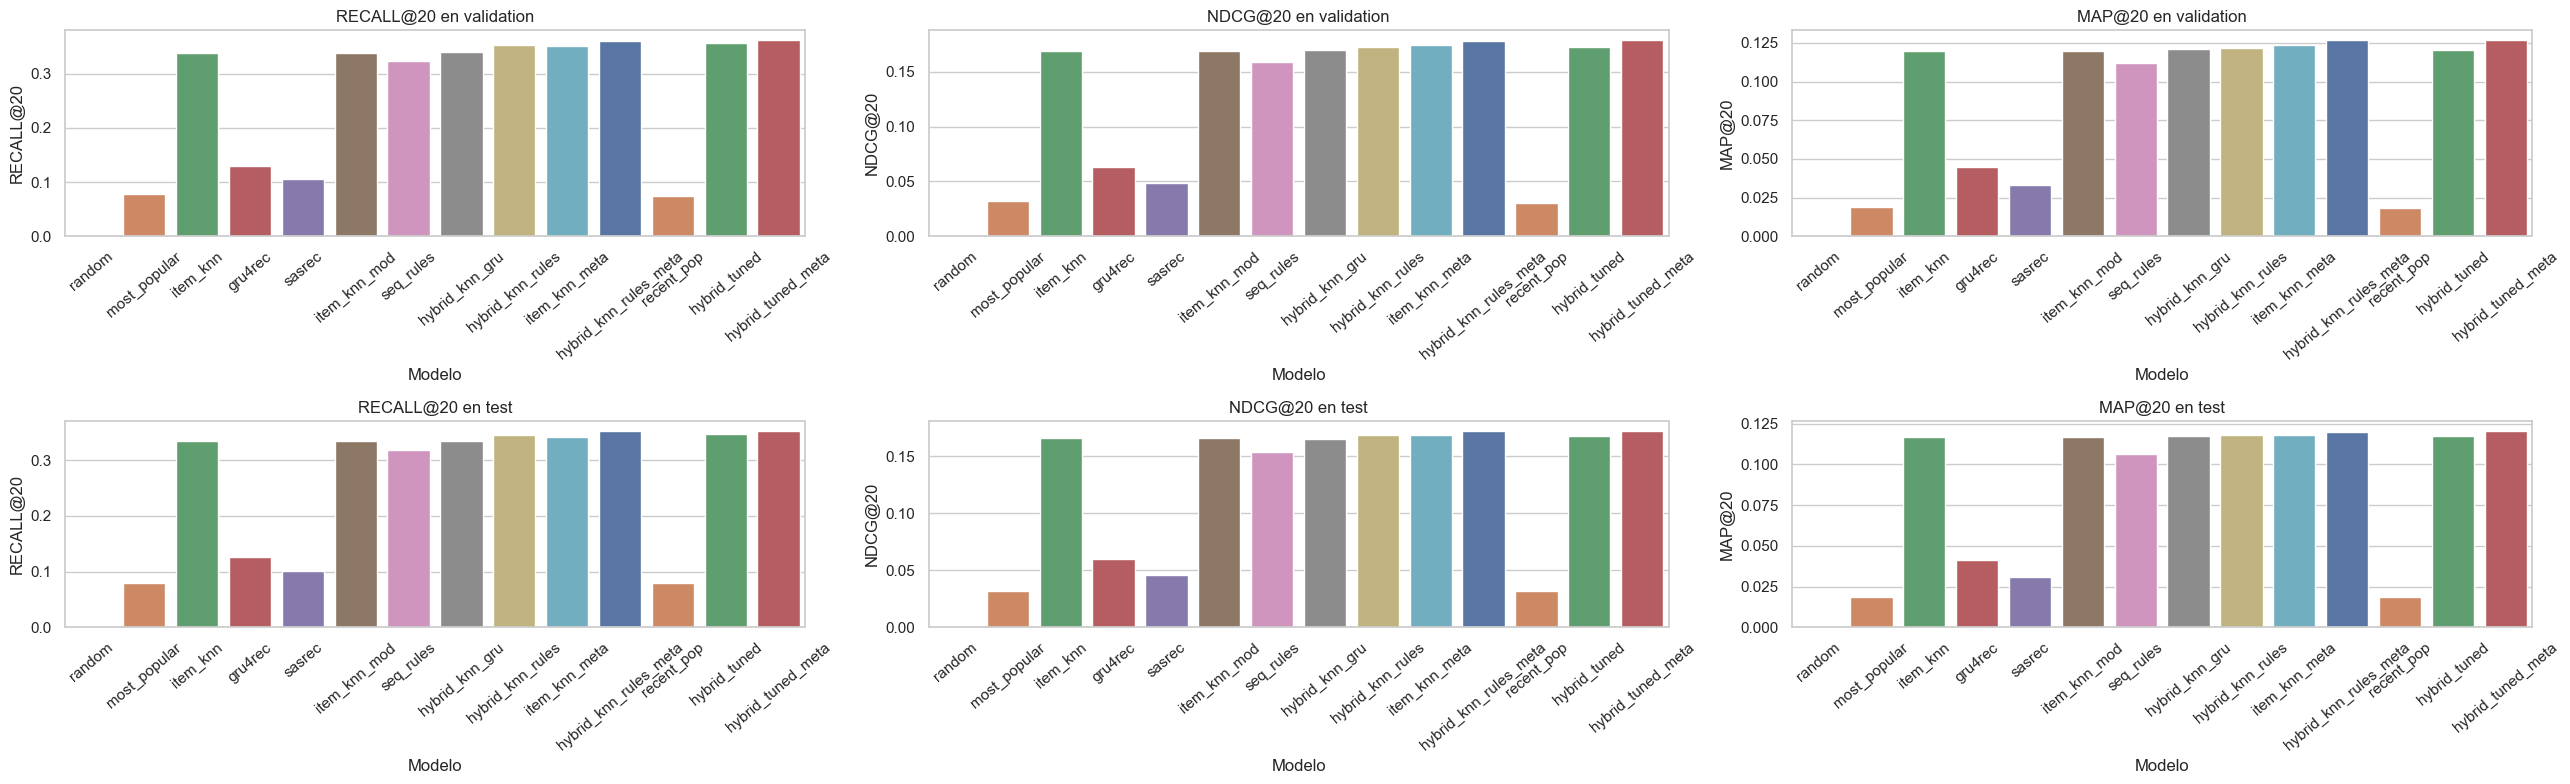

In [36]:
all_tuned_results = pd.concat(
    [
        all_metadata_results,
        tuned_results_val.assign(split="validation"),
        tuned_results_test.assign(split="test"),
    ],
    ignore_index=True,
)

display(all_tuned_results.sort_values(["split", "k", "recall"], ascending=[True, True, False]))

plot_df = all_tuned_results[all_tuned_results["k"] == 20].copy()
metrics = ["recall", "ndcg", "map"]
splits = ["validation", "test"]

fig, axes = plt.subplots(len(splits), len(metrics), figsize=(26, 8))

for row_idx, split in enumerate(splits):
    split_df = plot_df[plot_df["split"] == split].copy()

    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        sns.barplot(data=split_df, x="modelo", y=metric, hue="modelo", palette="deep", legend=False, ax=ax,)
        ax.set_title(f"{metric.upper()}@20 en {split}")
        ax.set_xlabel("Modelo")
        ax.set_ylabel(f"{metric.upper()}@20")
        ax.tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.show()


### 8. TALE (Temporal Linear Item-Item Model)

Se hace una version de `TALE`. Mantiene el split temporal y las metricas del notebook, pero por costo computacional limita el catálogo al top-N de `train`, ya que TALE aprende una matriz item-item densa en la forma cerrada.


In [37]:
tale_session_sequences = ConstruirSesionesConTiempo(events)

tale_train_raw, tale_val_raw, tale_test_raw = SepararSesionesPorVentanasDeTiempoTALE(
    tale_session_sequences,
    validation_days=VALIDATION_DAYS,
    test_days=TEST_DAYS,
)

tale_train_sessions, tale_val_sessions, tale_test_sessions = FiltrarItemsTrainYProyectarSplitsTALE(
    tale_train_raw,
    tale_val_raw,
    tale_test_raw,
    min_session_len=MIN_SESSION_LEN,
    min_item_support=MIN_ITEM_SUPPORT,
)

TALE_MAX_CATALOG_ITEMS = 2000
tale_train_sessions, tale_val_sessions, tale_test_sessions, tale_catalog_limited = LimitarCatalogoTALEPorPopularidad(
    tale_train_sessions,
    tale_val_sessions,
    tale_test_sessions,
    max_catalog_items=TALE_MAX_CATALOG_ITEMS,
    min_session_len=MIN_SESSION_LEN,
)

display(ConstruirResumenSplitsTALE(tale_train_sessions, tale_val_sessions, tale_test_sessions))
print(f"TALE se entrena sobre el top-{TALE_MAX_CATALOG_ITEMS:,} de items de train para mantener la forma cerrada manejable.")


,split,sesiones,interacciones,items_unicos,inicio,fin
0,train,34457,147811,2000,2019-11-01 00:15:29+00:00,2019-11-24 23:55:37+00:00
1,validation,2988,11651,1594,2019-11-25 00:02:43+00:00,2019-11-27 23:49:46+00:00
2,test,3146,12122,1523,2019-11-28 00:23:19+00:00,2019-11-30 23:57:02+00:00


TALE se entrena sobre el top-2,000 de items de train para mantener la forma cerrada manejable.


In [38]:
tale_val_eval = build_eval_cases(tale_val_sessions, max_session_len=MAX_SESSION_LEN)
tale_test_eval = build_eval_cases(tale_test_sessions, max_session_len=MAX_SESSION_LEN)

print(f"Casos TALE - validation: {len(tale_val_eval):,}, test: {len(tale_test_eval):,}")


Casos TALE - validation: 2,988, test: 3,146


In [39]:
tale_config_grid = HiperparametrosTALE()
tale_tuning_records = []

for config_name, config in tale_config_grid.items():
    tale_candidate = EntrenarTALE(tale_train_sessions, verbose=False, **config)
    tale_metrics = evaluate_recommender(tale_candidate.Recomendar, tale_val_eval, ks=[20], label=f"tale_{config_name}")
    best_row = tale_metrics.iloc[0]
    tale_tuning_records.append({
        "config": config_name,
        "recall@20": best_row["recall"],
        "ndcg@20": best_row["ndcg"],
        "map@20": best_row["map"],
        "lambda_reg": config["lambda_reg"],
        "c": config["c"],
        "tau_time_horas": config["tau_time"] / 3600.0,
        "window_days": config["window_days"],
    })

tale_tuning_results = pd.DataFrame(tale_tuning_records).sort_values(["recall@20", "ndcg@20"], ascending=False).reset_index(drop=True)
best_tale_config_name = tale_tuning_results.iloc[0]["config"]
best_tale_config = tale_config_grid[best_tale_config_name]

display(tale_tuning_results)
print(f"Mejor configuracion TALE en validation Recall@20: {best_tale_config_name}")


,config,recall@20,ndcg@20,map@20,lambda_reg,c,tau_time_horas,window_days
0,long_term,0.425033,0.207843,0.146059,300.0,0.3,24.0,14
1,balanced,0.422021,0.209599,0.149197,200.0,0.2,6.0,7
2,short_term,0.420683,0.211206,0.151879,100.0,0.1,2.0,3


Mejor configuracion TALE en validation Recall@20: long_term


In [40]:
tale_recommender = EntrenarTALE(tale_train_sessions, verbose=True, **best_tale_config)

tale_results_val = evaluate_recommender(tale_recommender.Recomendar, tale_val_eval, ks=TOP_KS, label="tale")
tale_results_test = evaluate_recommender(tale_recommender.Recomendar, tale_test_eval, ks=TOP_KS, label="tale")

print("Validation")
display(tale_results_val.sort_values(["k", "recall"], ascending=[True, False]))

print("Test")
display(tale_results_test.sort_values(["k", "recall"], ascending=[True, False]))


TALE: sesiones=34,457, ejemplos=113,354, items=2,000, lambda=300.000
Validation


,modelo,k,recall,ndcg,map
0,tale,5,0.223561,0.149921,0.125747
1,tale,10,0.320616,0.181320,0.138714
2,tale,20,0.425033,0.207843,0.146059


Test


,modelo,k,recall,ndcg,map
0,tale,5,0.217101,0.148228,0.125615
1,tale,10,0.323903,0.182741,0.139846
2,tale,20,0.418627,0.206736,0.146454


,modelo,k,recall,ndcg,map,split
87,tale,5,0.217101,0.148228,0.125615,test
81,hybrid_tuned_meta,5,0.189690,0.125244,0.104122,test
63,hybrid_knn_rules_meta,5,0.189238,0.124780,0.103599,test
60,item_knn_meta,5,0.186525,0.123091,0.102287,test
51,hybrid_knn_rules,5,0.182908,0.122081,0.102076,test
...,...,...,...,...,...,...
11,gru4rec,20,0.129383,0.063517,0.044915,validation
14,sasrec,20,0.105200,0.048706,0.033025,validation
5,most_popular,20,0.078597,0.031872,0.019082,validation
68,recent_pop,20,0.074244,0.030333,0.018166,validation


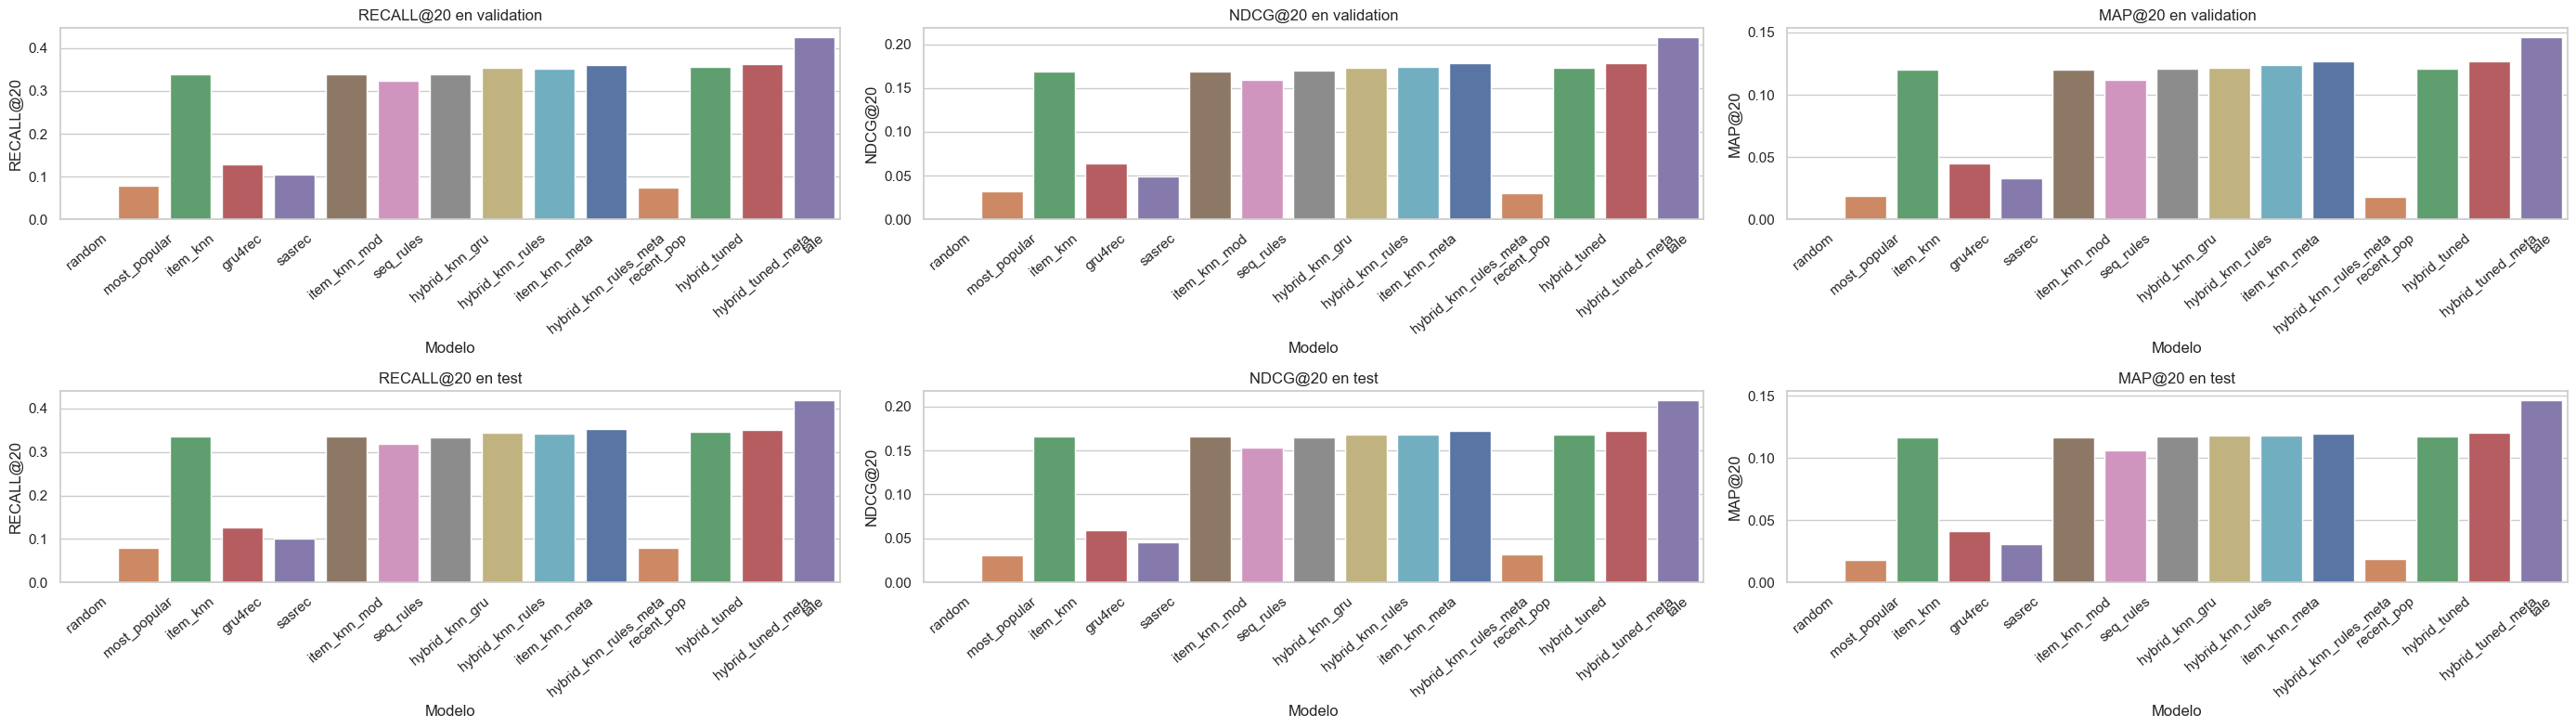

In [41]:
all_results_with_tale = pd.concat(
    [
        all_tuned_results,
        tale_results_val.assign(split="validation"),
        tale_results_test.assign(split="test"),
    ],
    ignore_index=True,
)

display(all_results_with_tale.sort_values(["split", "k", "recall"], ascending=[True, True, False]))

plot_df = all_results_with_tale[all_results_with_tale["k"] == 20].copy()
metrics = ["recall", "ndcg", "map"]
splits = ["validation", "test"]

fig, axes = plt.subplots(len(splits), len(metrics), figsize=(28, 8))

for row_idx, split in enumerate(splits):
    split_df = plot_df[plot_df["split"] == split].copy()

    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        sns.barplot(data=split_df, x="modelo", y=metric, hue="modelo", palette="deep", legend=False, ax=ax,)
        ax.set_title(f"{metric.upper()}@20 en {split}")
        ax.set_xlabel("Modelo")
        ax.set_ylabel(f"{metric.upper()}@20")
        ax.tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.show()


### 9. Analisis segmentado de resultados

Para entender mejor en que condiciones mejora cada variante de los modelos, se hace un analisis sobre `test` segmentando los casos por longitud de sesión, popularidad del item objetivo y disponibilidad de metadatos del target.


In [42]:
def evaluate_recommender_detailed(recommender_fn, eval_cases, ks=(5, 10, 20), label="model"):
    #Evalua cada caso individualmente para poder analizar despues los resultados por segmentos.
    rows = []
    max_k = max(ks)

    for case_idx, row in enumerate(eval_cases.itertuples(index=False)):
        relevant = {row.target_item}
        recs = recommender_fn(row.prefix_items, k=max_k, seen_items=row.seen_items)

        for k in ks:
            top_k = recs[:k]
            #rank guarda en que posicion aparece el target dentro del top-k, si aparece.
            rank = next((idx for idx, item in enumerate(top_k, start=1) if item in relevant), np.nan)
            rows.append({
                "case_id": case_idx,
                "modelo": label,
                "k": k,
                "recall": recall_at_k(recs, relevant, k),
                "ndcg": ndcg_at_k(recs, relevant, k),
                "map": average_precision_at_k(recs, relevant, k),
                "hit": float(not np.isnan(rank)),
                "rank": rank,
            })

    return pd.DataFrame(rows)


def build_segmented_eval_cases(eval_cases, train_sessions, item_metadata):
    #Enriquece los casos de evaluacion con variables de análisis como longitud de sesión, popularidad del target y disponibilidad de metadatos.
    casos = eval_cases.copy().reset_index(drop=True)
    casos["case_id"] = np.arange(len(casos))
    casos["prefix_len"] = casos["prefix_items"].apply(len)
    casos["session_len_total"] = casos["prefix_len"] + 1

    #Agrupa sesiones en buckets simples para comparar modelos según cantidad de contexto.
    casos["session_len_bucket"] = pd.cut(
        casos["session_len_total"],
        bins=[1, 3, 6, np.inf],
        labels=["corta_2_3", "media_4_6", "larga_7_plus"],
        include_lowest=True,
        right=True,
    )

    item_support = Counter(item for seq in train_sessions["items"] for item in seq)
    ranked_items = [item for item, _ in item_support.most_common()]
    item_rank = {item: rank for rank, item in enumerate(ranked_items, start=1)}
    n_items = max(len(ranked_items), 1)
    head_cut = max(1, int(np.ceil(0.20 * n_items)))
    mid_cut = max(head_cut + 1, int(np.ceil(0.50 * n_items)))

    casos["target_support_train"] = casos["target_item"].map(item_support).fillna(0).astype(int)
    casos["target_pop_rank"] = casos["target_item"].map(item_rank).fillna(n_items + 1).astype(int)
    
    #Divide el target en head, mid y tail segun su popularidad en train.
    casos["target_pop_bucket"] = np.where(
        casos["target_pop_rank"] <= head_cut,
        "head",
        np.where(casos["target_pop_rank"] <= mid_cut, "mid", "tail"),
    )

    #Resume cuanta metadata util tiene el item objetivo.
    metadata_lookup = item_metadata.set_index("product_id")[ ["category_code", "brand", "category_root"] ].copy()
    metadata_lookup["target_has_category"] = metadata_lookup["category_code"].fillna("unknown").ne("unknown")
    metadata_lookup["target_has_brand"] = metadata_lookup["brand"].fillna("unknown").ne("unknown")
    
    #Resume cuanta metadata útil tiene el item objetivo.
    metadata_lookup["target_metadata_bucket"] = np.select(
        [
            metadata_lookup["target_has_category"] & metadata_lookup["target_has_brand"],
            metadata_lookup["target_has_category"] | metadata_lookup["target_has_brand"],
        ],
        ["metadata_completa", "metadata_parcial"],
        default="sin_metadata",
    )

    casos = casos.merge(
        metadata_lookup[["target_has_category", "target_has_brand", "target_metadata_bucket"]],
        how="left",
        left_on="target_item",
        right_index=True,
    )
    casos["target_has_category"] = casos["target_has_category"].fillna(False)
    casos["target_has_brand"] = casos["target_has_brand"].fillna(False)
    casos["target_metadata_bucket"] = casos["target_metadata_bucket"].fillna("sin_metadata")
    return casos


def resumir_metricas_por_segmento(detailed_results, segmented_cases, segment_col, ks=(5, 10, 20)):
    #Agrega las metricas promedio por modelo, k y segmento del dataset.
    merged = detailed_results.merge(segmented_cases[["case_id", segment_col]], on="case_id", how="left")
    resumen = (
        merged[merged["k"].isin(ks)]
        .groupby(["modelo", "k", segment_col], observed=True)
        .agg(
            casos=("case_id", "nunique"),
            recall=("recall", "mean"),
            ndcg=("ndcg", "mean"),
            map=("map", "mean"),
            hit_rate=("hit", "mean"),
            mean_rank=("rank", "mean"),
        )
        .reset_index()
    )
    return resumen


def construir_delta_segmento(segment_summary, base_model, improved_model, segment_col, k=20):
    #Compara dos modelos dentro de cada segmento y mide cuanto mejora el segundo sobre el primero.
    subset = segment_summary[segment_summary["k"] == k].copy()
    base = subset[subset["modelo"] == base_model].set_index(segment_col)[["recall", "ndcg", "map"]]
    improved = subset[subset["modelo"] == improved_model].set_index(segment_col)[["recall", "ndcg", "map"]]
    delta = improved.subtract(base, fill_value=np.nan).reset_index()
    delta.insert(0, "comparacion", f"{improved_model} - {base_model}")
    return delta


In [43]:
#Construye la version mejorada de test para estudiar en que segmentos cambia el rendimiento.
segmented_test_cases = build_segmented_eval_cases(test_eval, train_sessions, item_metadata)

display(
    segmented_test_cases[[
        "prefix_len",
        "session_len_total",
        "session_len_bucket",
        "target_support_train",
        "target_pop_bucket",
        "target_metadata_bucket",
    ]].head()
)

for column in ["session_len_bucket", "target_pop_bucket", "target_metadata_bucket"]:
    print(f"\nDistribucion de casos por {column}:")
    display(segmented_test_cases[column].value_counts(dropna=False).rename_axis(column).reset_index(name="casos"))


,prefix_len,session_len_total,session_len_bucket,target_support_train,target_pop_bucket,target_metadata_bucket
0,1,2,corta_2_3,12,mid,metadata_parcial
1,7,8,larga_7_plus,287,head,metadata_completa
2,3,4,media_4_6,6,tail,metadata_completa
3,4,5,media_4_6,39,head,metadata_completa
4,4,5,media_4_6,9,tail,metadata_completa



Distribucion de casos por session_len_bucket:


,session_len_bucket,casos
0,corta_2_3,2522
1,media_4_6,1189
2,larga_7_plus,712



Distribucion de casos por target_pop_bucket:


,target_pop_bucket,casos
0,head,2984
1,mid,739
2,tail,700



Distribucion de casos por target_metadata_bucket:


,target_metadata_bucket,casos
0,metadata_completa,3093
1,metadata_parcial,1023
2,sin_metadata,307


In [44]:
#Subconjunto de modelos representativos para el análisis segmentado.
segment_models = [
    ("item_knn", item_knn_recommender.Recomendar),
    ("gru4rec", gru4rec_recommender.Recomendar),
    ("sasrec", sasrec_recommender.Recomendar),
    ("hybrid_knn_rules", hybrid_knn_rules_recommender.Recomendar),
    ("item_knn_meta", item_knn_meta_recommender.Recomendar),
    ("hybrid_tuned", best_hybrid_tuned_recommender.Recomendar),
    ("hybrid_tuned_meta", best_hybrid_tuned_meta_recommender.Recomendar),
]

#Guarda las métricas caso por caso para cada modelo y cada valor de k.
detailed_segment_results = pd.concat(
    [
        evaluate_recommender_detailed(recommender_fn, segmented_test_cases, ks=TOP_KS, label=label)
        for label, recommender_fn in segment_models
    ],
    ignore_index=True,
)

display(detailed_segment_results.head())


,case_id,modelo,k,recall,ndcg,map,hit,rank
0,0,item_knn,5,1.0,1.0,1.0,1.0,1.0
1,0,item_knn,10,1.0,1.0,1.0,1.0,1.0
2,0,item_knn,20,1.0,1.0,1.0,1.0,1.0
3,1,item_knn,5,0.0,0.0,0.0,0.0,NaN
4,1,item_knn,10,0.0,0.0,0.0,0.0,NaN


In [45]:
#Resume resultados por los tres focos de analisis longitud de sesion, popularidad del target y disponibilidad de metadata.

session_length_summary = resumir_metricas_por_segmento(
    detailed_segment_results, segmented_test_cases, "session_len_bucket", ks=TOP_KS
)
target_pop_summary = resumir_metricas_por_segmento(
    detailed_segment_results, segmented_test_cases, "target_pop_bucket", ks=TOP_KS
)
metadata_summary = resumir_metricas_por_segmento(
    detailed_segment_results, segmented_test_cases, "target_metadata_bucket", ks=TOP_KS
)

print("Longitud de sesion - metricas por segmento")
display(session_length_summary.sort_values(["k", "session_len_bucket", "recall"], ascending=[True, True, False]))

print("Popularidad del target - metricas por segmento")
display(target_pop_summary.sort_values(["k", "target_pop_bucket", "recall"], ascending=[True, True, False]))

print("Disponibilidad de metadata - metricas por segmento")
display(metadata_summary.sort_values(["k", "target_metadata_bucket", "recall"], ascending=[True, True, False]))


Longitud de sesion - metricas por segmento


,modelo,k,session_len_bucket,casos,recall,ndcg,map,hit_rate,mean_rank
27,hybrid_tuned_meta,5,corta_2_3,2522,0.230373,0.152899,0.127465,0.230373,2.535284
45,item_knn_meta,5,corta_2_3,2522,0.227994,0.149615,0.123863,0.227994,2.561739
9,hybrid_knn_rules,5,corta_2_3,2522,0.221649,0.150340,0.126870,0.221649,2.449016
18,hybrid_tuned,5,corta_2_3,2522,0.219270,0.149338,0.126322,0.219270,2.437613
36,item_knn,5,corta_2_3,2522,0.217288,0.147419,0.124432,0.217288,2.450730
...,...,...,...,...,...,...,...,...,...
44,item_knn,20,larga_7_plus,712,0.228933,0.106441,0.071556,0.228933,6.932515
17,hybrid_knn_rules,20,larga_7_plus,712,0.227528,0.104168,0.069438,0.227528,7.450617
26,hybrid_tuned,20,larga_7_plus,712,0.223315,0.102353,0.068259,0.223315,7.308176
8,gru4rec,20,larga_7_plus,712,0.068820,0.028782,0.017946,0.068820,9.000000


Popularidad del target - metricas por segmento


,modelo,k,target_pop_bucket,casos,recall,ndcg,map,hit_rate,mean_rank
27,hybrid_tuned_meta,5,head,2984,0.218164,0.145653,0.121816,0.218164,2.505376
9,hybrid_knn_rules,5,head,2984,0.215147,0.145666,0.122744,0.215147,2.437695
18,hybrid_tuned,5,head,2984,0.213137,0.144674,0.122118,0.213137,2.441824
45,item_knn_meta,5,head,2984,0.209786,0.139600,0.116499,0.209786,2.501597
36,item_knn,5,head,2984,0.209115,0.141107,0.118711,0.209115,2.461538
...,...,...,...,...,...,...,...,...,...
44,item_knn,20,tail,700,0.225714,0.113020,0.080655,0.225714,6.139241
17,hybrid_knn_rules,20,tail,700,0.215714,0.102306,0.069827,0.215714,6.602649
26,hybrid_tuned,20,tail,700,0.212857,0.098583,0.066229,0.212857,7.120805
8,gru4rec,20,tail,700,0.000000,0.000000,0.000000,0.000000,NaN


Disponibilidad de metadata - metricas por segmento


,modelo,k,target_metadata_bucket,casos,recall,ndcg,map,hit_rate,mean_rank
27,hybrid_tuned_meta,5,metadata_completa,3093,0.212738,0.141305,0.117841,0.212738,2.527356
45,item_knn_meta,5,metadata_completa,3093,0.211445,0.138853,0.115061,0.211445,2.581040
9,hybrid_knn_rules,5,metadata_completa,3093,0.203686,0.137050,0.115115,0.203686,2.476190
18,hybrid_tuned,5,metadata_completa,3093,0.200776,0.134826,0.113110,0.200776,2.479871
36,item_knn,5,metadata_completa,3093,0.198836,0.133768,0.112377,0.198836,2.484553
...,...,...,...,...,...,...,...,...,...
17,hybrid_knn_rules,20,sin_metadata,307,0.211726,0.102741,0.071567,0.211726,6.676923
53,item_knn_meta,20,sin_metadata,307,0.211726,0.091645,0.057042,0.211726,6.969231
44,item_knn,20,sin_metadata,307,0.201954,0.098820,0.069015,0.201954,6.112903
8,gru4rec,20,sin_metadata,307,0.013029,0.005560,0.003312,0.013029,5.500000


In [46]:
#Se mide si el reranking con metadatos agrega valor real sobre el modelo base en cada segmento.

delta_item_knn_meta_by_length = construir_delta_segmento(session_length_summary, "item_knn", "item_knn_meta", "session_len_bucket", k=20)
delta_hybrid_meta_by_length = construir_delta_segmento(session_length_summary, "hybrid_tuned", "hybrid_tuned_meta", "session_len_bucket", k=20)

delta_item_knn_meta_by_pop = construir_delta_segmento(target_pop_summary, "item_knn", "item_knn_meta", "target_pop_bucket", k=20)
delta_hybrid_meta_by_pop = construir_delta_segmento(target_pop_summary, "hybrid_tuned", "hybrid_tuned_meta", "target_pop_bucket", k=20)

delta_item_knn_meta_by_metadata = construir_delta_segmento(metadata_summary, "item_knn", "item_knn_meta", "target_metadata_bucket", k=20)
delta_hybrid_meta_by_metadata = construir_delta_segmento(metadata_summary, "hybrid_tuned", "hybrid_tuned_meta", "target_metadata_bucket", k=20)

print("Aporte del reranking con metadatos sobre Item-KNN a Recall/NDCG/MAP@20")
display(pd.concat([delta_item_knn_meta_by_length, delta_item_knn_meta_by_pop, delta_item_knn_meta_by_metadata], ignore_index=True))

print("Aporte del reranking con metadatos sobre el hibrido ajustado a Recall/NDCG/MAP@20")
display(pd.concat([delta_hybrid_meta_by_length, delta_hybrid_meta_by_pop, delta_hybrid_meta_by_metadata], ignore_index=True))


Aporte del reranking con metadatos sobre Item-KNN a Recall/NDCG/MAP@20


,comparacion,session_len_bucket,recall,ndcg,map,target_pop_bucket,target_metadata_bucket
0,item_knn_meta - item_knn,corta_2_3,0.006741,1.208058e-03,-0.000819,NaN,NaN
1,item_knn_meta - item_knn,media_4_6,0.010093,5.659182e-03,0.004405,NaN,NaN
2,item_knn_meta - item_knn,larga_7_plus,0.002809,3.453626e-03,0.003523,NaN,NaN
3,item_knn_meta - item_knn,NaN,0.004692,5.608194e-07,-0.001495,head,NaN
4,item_knn_meta - item_knn,NaN,0.004060,8.690590e-03,0.009132,mid,NaN
5,item_knn_meta - item_knn,NaN,0.020000,8.300644e-03,0.004846,tail,NaN
6,item_knn_meta - item_knn,NaN,0.007113,3.449836e-03,0.002069,NaN,metadata_completa
7,item_knn_meta - item_knn,NaN,0.005865,3.682401e-03,0.002889,NaN,metadata_parcial
8,item_knn_meta - item_knn,NaN,0.009772,-7.175797e-03,-0.011974,NaN,sin_metadata


Aporte del reranking con metadatos sobre el hibrido ajustado a Recall/NDCG/MAP@20


,comparacion,session_len_bucket,recall,ndcg,map,target_pop_bucket,target_metadata_bucket
0,hybrid_tuned_meta - hybrid_tuned,corta_2_3,0.004758,0.001905,0.000598,NaN,NaN
1,hybrid_tuned_meta - hybrid_tuned,media_4_6,0.004205,0.006573,0.007094,NaN,NaN
2,hybrid_tuned_meta - hybrid_tuned,larga_7_plus,0.011236,0.006832,0.005877,NaN,NaN
3,hybrid_tuned_meta - hybrid_tuned,NaN,0.002346,0.000120,-0.000672,head,NaN
4,hybrid_tuned_meta - hybrid_tuned,NaN,0.006766,0.012538,0.013458,mid,NaN
5,hybrid_tuned_meta - hybrid_tuned,NaN,0.018571,0.011228,0.008836,tail,NaN
6,hybrid_tuned_meta - hybrid_tuned,NaN,0.008406,0.005496,0.004396,NaN,metadata_completa
7,hybrid_tuned_meta - hybrid_tuned,NaN,-0.001955,0.001703,0.002498,NaN,metadata_parcial
8,hybrid_tuned_meta - hybrid_tuned,NaN,0.003257,-0.004101,-0.006600,NaN,sin_metadata


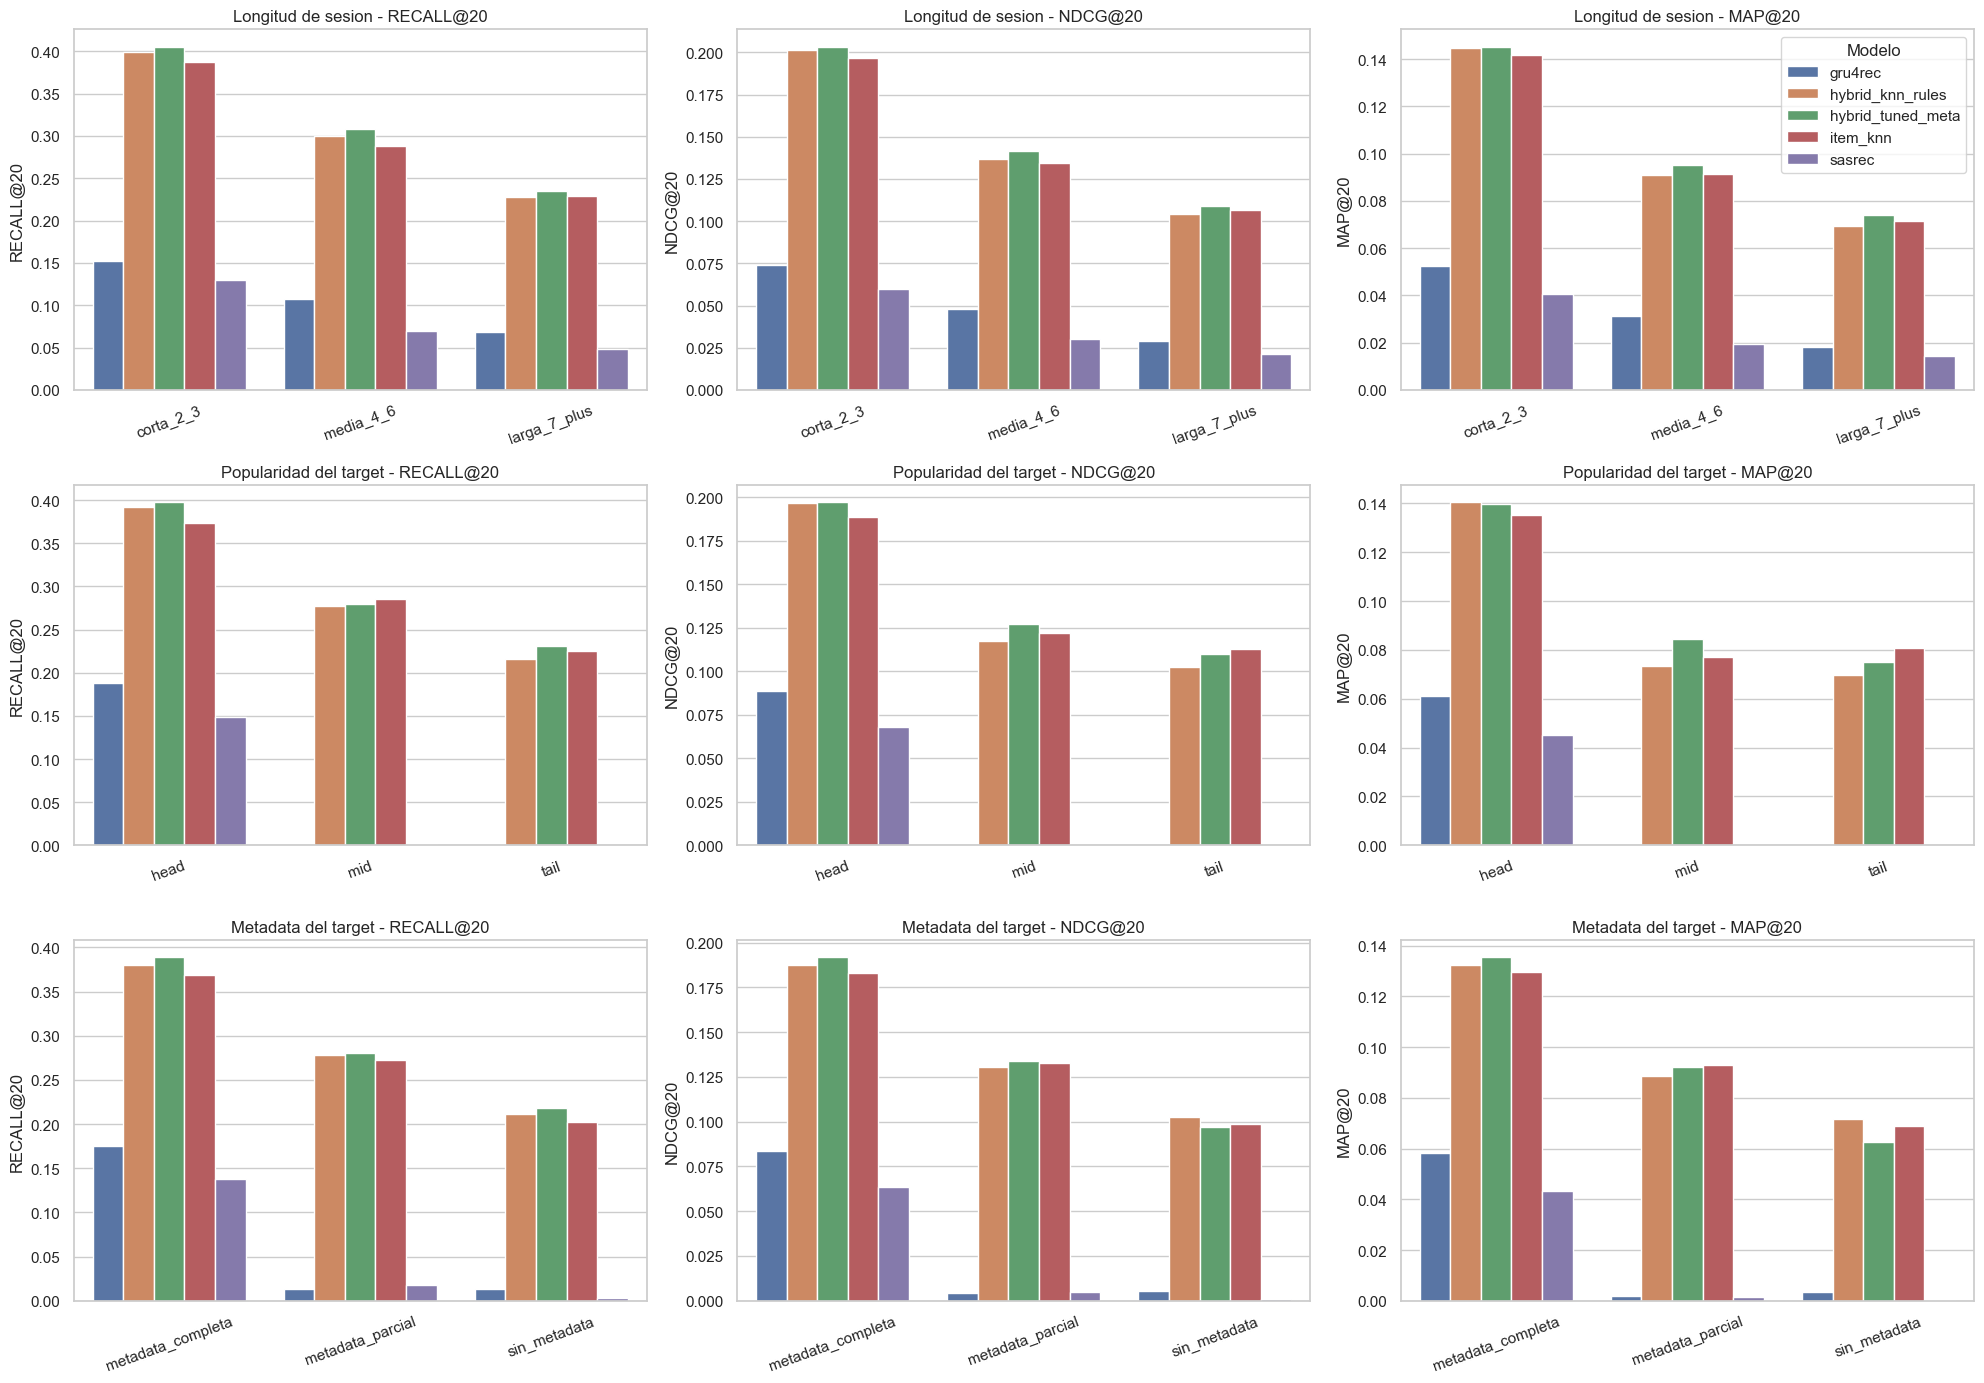

In [47]:
plot_models = ["item_knn", "gru4rec", "sasrec", "hybrid_knn_rules", "hybrid_tuned_meta"]

fig, axes = plt.subplots(3, 3, figsize=(20, 14))
plot_specs = [
    (session_length_summary, "session_len_bucket", "Longitud de sesion"),
    (target_pop_summary, "target_pop_bucket", "Popularidad del target"),
    (metadata_summary, "target_metadata_bucket", "Metadata del target"),
]
metrics = ["recall", "ndcg", "map"]

for row_idx, (summary_df, segment_col, title_prefix) in enumerate(plot_specs):
    subset = summary_df[(summary_df["k"] == 20) & (summary_df["modelo"].isin(plot_models))].copy()
    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        sns.barplot(data=subset, x=segment_col, y=metric, hue="modelo", palette="deep", ax=ax)
        ax.set_title(f"{title_prefix} - {metric.upper()}@20")
        ax.set_xlabel("")
        ax.set_ylabel(f"{metric.upper()}@20")
        ax.tick_params(axis="x", rotation=20)
        if row_idx != 0 or col_idx != 2:
            ax.get_legend().remove()

handles, labels = axes[0, 2].get_legend_handles_labels()
axes[0, 2].legend(handles, labels, title="Modelo", loc="best")
plt.tight_layout()
plt.show()


### 10. Inspección cualitativa de recomendaciones

Además de las métricas, se revisan ejemplos concretos del conjunto de test para entender que productos forman la secuencia observada, cual es el target real y que top-k recomienda el mejor modelo comparable del pipeline principal, `hybrid_tuned_meta`. En los graficos de abajo, el target real aparece al final de la secuencia observada y, en la grilla de recomendaciones, se marca en verde cuando el modelo lo incluye dentro de su top-k.


In [48]:
import importlib
import ECommerce_Recommendation_Examples as ere

importlib.reload(ere)

ConstruirCatalogoProductosVisual = ere.ConstruirCatalogoProductosVisual
SeleccionarCasosEjemplo = ere.SeleccionarCasosEjemplo
ConstruirTablaSecuenciaCaso = ere.ConstruirTablaSecuenciaCaso
ConstruirTablaRecomendacionesCaso = ere.ConstruirTablaRecomendacionesCaso
PlotComparacionRecomendacionesCaso = ere.PlotComparacionRecomendacionesCaso

product_catalog_visual = ConstruirCatalogoProductosVisual(events)
product_lookup_visual = product_catalog_visual.set_index("product_id").to_dict(orient="index")

best_model_recommenders = [
    ("hybrid_tuned_meta", best_hybrid_tuned_meta_recommender.Recomendar),
]

example_cases = SeleccionarCasosEjemplo(
    test_eval,
    best_hybrid_tuned_meta_recommender.Recomendar,
    product_lookup_visual,
    k=5,
)

display(example_cases)


,case_idx,bucket,prefix_len,target_item,target_desc
0,4410,corta,3,1005101,id=1005101 | cat=electronics | brand=xiaomi | ...
1,3624,media,6,1307184,id=1307184 | cat=computers | brand=lenovo | pr...
2,4360,larga,20,1004932,id=1004932 | cat=electronics | brand=vivo | pr...


Caso de test #4410


,rol,resumen,descripcion
0,prefijo_1,electronics | oneplus | $540.30,id=1004993 | cat=electronics | brand=oneplus |...
1,prefijo_2,electronics | xiaomi | $202.50,id=1005159 | cat=electronics | brand=xiaomi | ...
2,prefijo_3,electronics | xiaomi | $444.51,id=1005102 | cat=electronics | brand=xiaomi | ...
3,target_real,electronics | xiaomi | $429.57,id=1005101 | cat=electronics | brand=xiaomi | ...


,modelo,rank,resumen,descripcion,es_target
0,hybrid_tuned_meta,1,electronics | xiaomi | $429.57,id=1005101 | cat=electronics | brand=xiaomi | ...,True
1,hybrid_tuned_meta,2,electronics | xiaomi | $336.69,id=1004958 | cat=electronics | brand=xiaomi | ...,False
2,hybrid_tuned_meta,3,electronics | xiaomi | $446.34,id=1005196 | cat=electronics | brand=xiaomi | ...,False
3,hybrid_tuned_meta,4,electronics | xiaomi | $290.09,id=1005158 | cat=electronics | brand=xiaomi | ...,False
4,hybrid_tuned_meta,5,electronics | xiaomi | $288.04,id=1005253 | cat=electronics | brand=xiaomi | ...,False


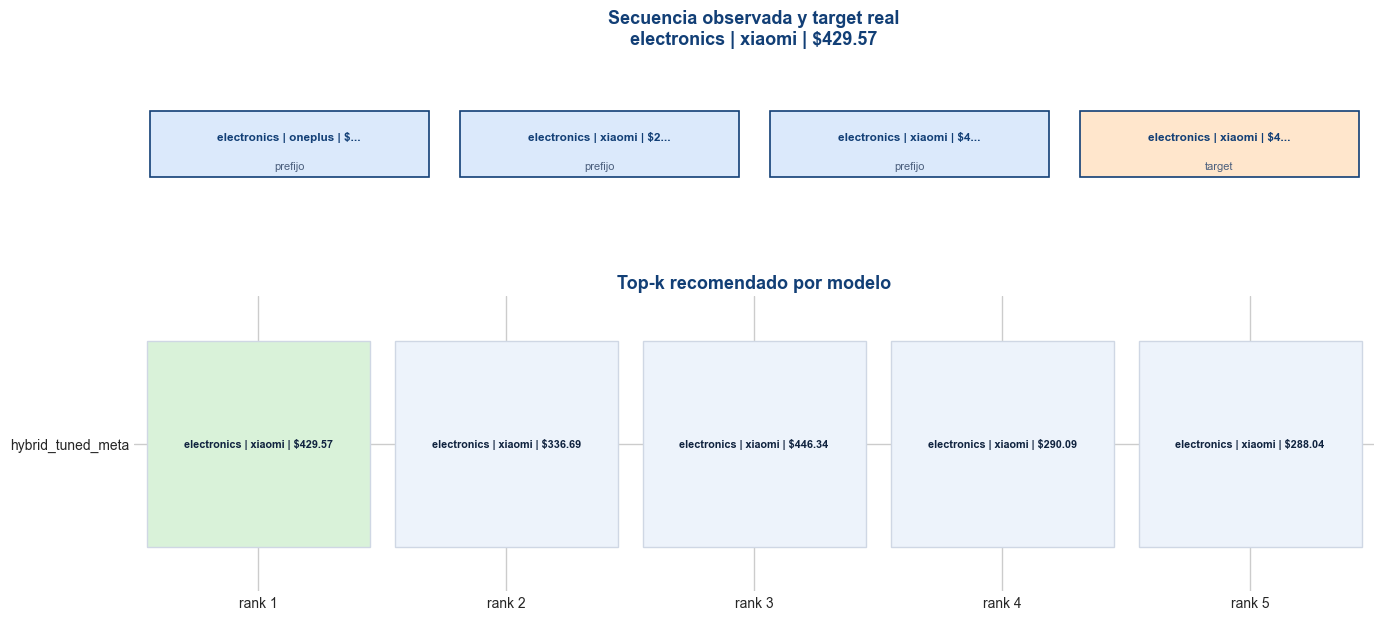

Caso de test #3624


,rol,resumen,descripcion
0,prefijo_1,computers | asus | $668.34,id=1307076 | cat=computers | brand=asus | pric...
1,prefijo_2,computers | acer | $875.16,id=1307194 | cat=computers | brand=acer | pric...
2,prefijo_3,computers | acer | $771.93,id=1306413 | cat=computers | brand=acer | pric...
3,prefijo_4,computers | acer | $1001.29,id=1307571 | cat=computers | brand=acer | pric...
4,prefijo_5,computers | asus | $952.38,id=1307536 | cat=computers | brand=asus | pric...
5,prefijo_6,computers | lenovo | $669.23,id=1306830 | cat=computers | brand=lenovo | pr...
6,target_real,computers | lenovo | $821.10,id=1307184 | cat=computers | brand=lenovo | pr...


,modelo,rank,resumen,descripcion,es_target
0,hybrid_tuned_meta,1,computers | lenovo | $694.97,id=1306608 | cat=computers | brand=lenovo | pr...,False
1,hybrid_tuned_meta,2,computers | lenovo | $821.10,id=1307184 | cat=computers | brand=lenovo | pr...,True
2,hybrid_tuned_meta,3,computers | lenovo | $849.42,id=1307520 | cat=computers | brand=lenovo | pr...,False
3,hybrid_tuned_meta,4,computers | hp | $694.74,id=1306380 | cat=computers | brand=hp | price=...,False
4,hybrid_tuned_meta,5,computers | lenovo | $669.23,id=1306984 | cat=computers | brand=lenovo | pr...,False


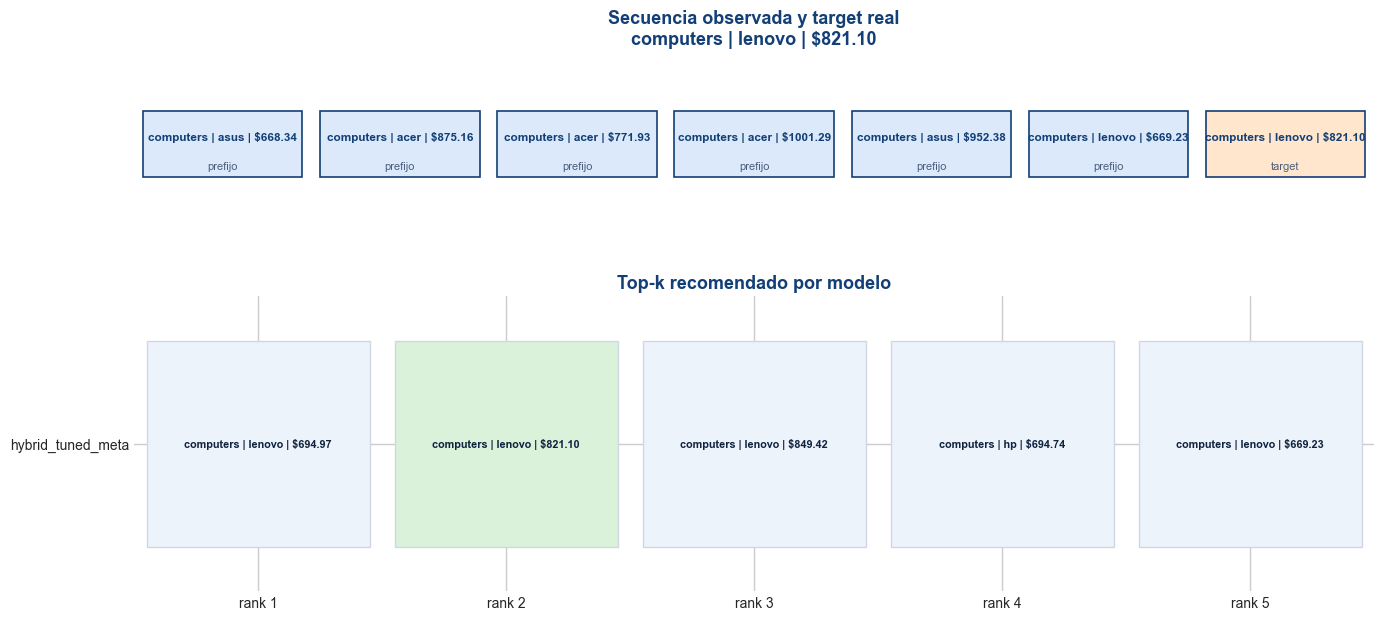

Caso de test #4360


,rol,resumen,descripcion
0,prefijo_1,electronics | huawei | $264.71,id=1004785 | cat=electronics | brand=huawei | ...
1,prefijo_2,electronics | huawei | $945.97,id=100017960 | cat=electronics | brand=huawei ...
2,prefijo_3,electronics | samsung | $353.92,id=1004873 | cat=electronics | brand=samsung |...
3,prefijo_4,electronics | samsung | $715.33,id=1004659 | cat=electronics | brand=samsung |...
4,prefijo_5,electronics | samsung | $741.33,id=1004158 | cat=electronics | brand=samsung |...
5,prefijo_6,electronics | samsung | $2562.49,id=1005284 | cat=electronics | brand=samsung |...
6,prefijo_7,electronics | samsung | $633.46,id=1004648 | cat=electronics | brand=samsung |...
7,prefijo_8,electronics | samsung | $2562.49,id=100015658 | cat=electronics | brand=samsung...
8,prefijo_9,electronics | honor | $283.12,id=1005229 | cat=electronics | brand=honor | p...
9,prefijo_10,electronics | honor | $308.63,id=1004307 | cat=electronics | brand=honor | p...


,modelo,rank,resumen,descripcion,es_target
0,hybrid_tuned_meta,1,electronics | vivo | $308.86,id=1005070 | cat=electronics | brand=vivo | pr...,False
1,hybrid_tuned_meta,2,electronics | vivo | $218.77,id=1004934 | cat=electronics | brand=vivo | pr...,False
2,hybrid_tuned_meta,3,electronics | vivo | $463.31,id=1005243 | cat=electronics | brand=vivo | pr...,False
3,hybrid_tuned_meta,4,electronics | vivo | $437.33,id=1004932 | cat=electronics | brand=vivo | pr...,True
4,hybrid_tuned_meta,5,electronics | vivo | $463.31,id=1005244 | cat=electronics | brand=vivo | pr...,False


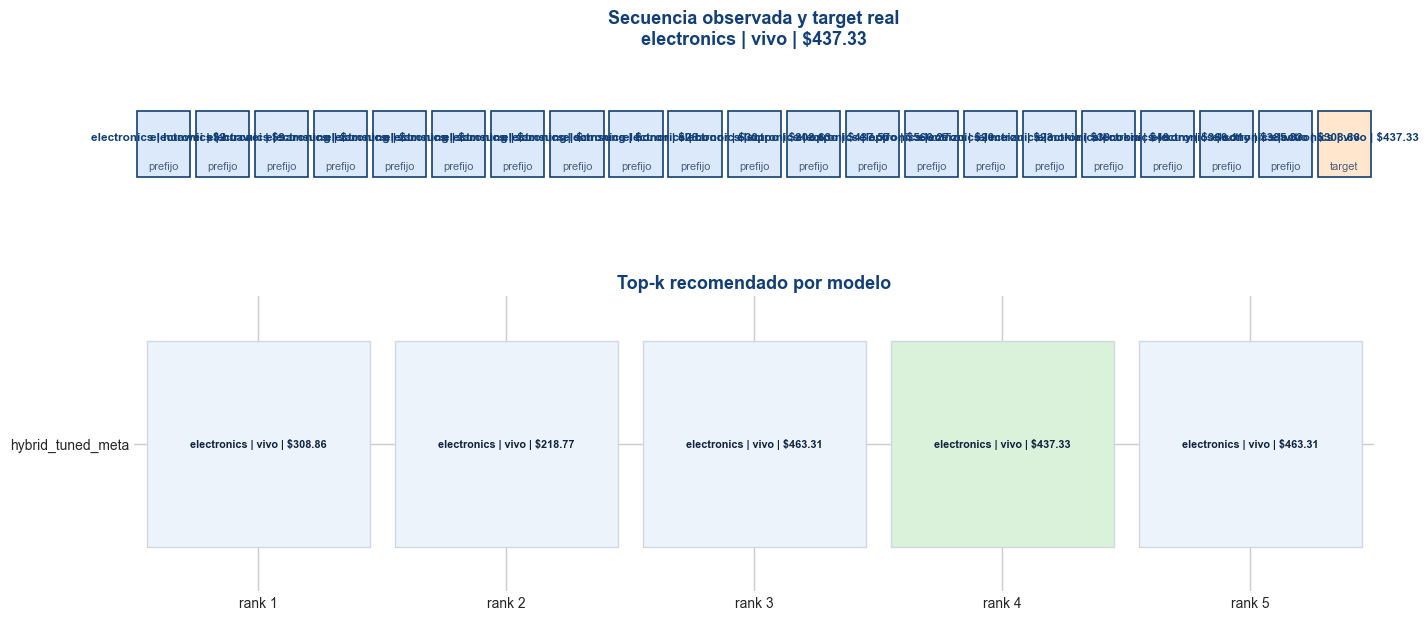

In [49]:
for case_idx in example_cases["case_idx"]:
    case_row = test_eval.iloc[int(case_idx)]
    print(f"Caso de test #{int(case_idx)}")
    display(
        ConstruirTablaSecuenciaCaso(case_row, product_lookup_visual)[
            ["rol", "resumen", "descripcion"]
        ]
    )

    case_recommendations = ConstruirTablaRecomendacionesCaso(
        case_row,
        best_model_recommenders,
        product_lookup_visual,
        k=5,
    )
    display(
        case_recommendations[
            ["modelo", "rank", "resumen", "descripcion", "es_target"]
        ]
    )

    PlotComparacionRecomendacionesCaso(
        case_row,
        case_recommendations,
        product_lookup_visual,
        k=5,
        figsize=(16, 7),
    )
    plt.show()


### 11. Exportación de resultados


In [59]:
import importlib
import ECommerce_Exports
importlib.reload(ECommerce_Exports)

from ECommerce_Exports import ExportarDataFramesExcel

export_tables = {
    "split_summary": split_summary,
    "final_results": all_results_with_tale,
    "segment_session_len": session_length_summary,
    "segment_target_pop": target_pop_summary,
    "segment_metadata": metadata_summary,
}

export_path = ExportarDataFramesExcel(
    export_tables, "ecommerce_results.xlsx",
)

print(f"Resultados exportados a: {export_path}")


Resultados exportados a: ecommerce_results.xlsx
